In [ ]:
from google.colab import files

uploaded = files.upload()

Saving titanic_train.csv to titanic_train.csv


In [ ]:
import os

print(os.listdir())

['.config', 'titanic_train.csv', 'assets', 'sample_data']


In [ ]:
df = pd.read_csv("titanic_train.csv")

In [1]:
# ============================================================
# WEEK 4: MACHINE LEARNING MODEL DEVELOPMENT AND EVALUATION
# Dataset: Titanic
# ============================================================

# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)


# ------------------------------------------------------------
# 2. CREATE ASSETS FOLDER
# ------------------------------------------------------------

os.makedirs("assets", exist_ok=True)


# ------------------------------------------------------------
# 3. LOAD DATASET
# ------------------------------------------------------------

file_path = "titanic_train.csv"

df = pd.read_csv(file_path)

print("\n========== DATASET LOADED ==========")
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())


# ------------------------------------------------------------
# 4. BASIC DATASET INFORMATION
# ------------------------------------------------------------

print("\n========== DATASET INFORMATION ==========")
print(df.info())

print("\n========== DESCRIPTIVE STATISTICS ==========")
print(df.describe())

print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())


# ------------------------------------------------------------
# 5. MISSING VALUE VISUALIZATION
# ------------------------------------------------------------

missing = df.isnull().sum()
missing = missing[missing > 0]

plt.figure(figsize=(8, 5))
missing.plot(kind="bar")
plt.title("Missing Values by Feature")
plt.xlabel("Features")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("assets/missing_values.png", dpi=300)
plt.show()


# ------------------------------------------------------------
# 6. TARGET DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))
df["Survived"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Titanic Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("assets/target_distribution.png", dpi=300)
plt.show()


# ------------------------------------------------------------
# 7. SURVIVAL BY SEX
# ------------------------------------------------------------

survival_sex = pd.crosstab(
    df["Sex"],
    df["Survived"],
    normalize="index"
) * 100

survival_sex.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(["Did Not Survive", "Survived"])
plt.tight_layout()
plt.savefig("assets/survival_by_sex.png", dpi=300)
plt.show()


# ------------------------------------------------------------
# 8. SURVIVAL BY PASSENGER CLASS
# ------------------------------------------------------------

survival_class = pd.crosstab(
    df["Pclass"],
    df["Survived"],
    normalize="index"
) * 100

survival_class.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(["Did Not Survive", "Survived"])
plt.tight_layout()
plt.savefig("assets/survival_by_class.png", dpi=300)
plt.show()


# ------------------------------------------------------------
# 9. DATA PREPROCESSING
# ------------------------------------------------------------

# Select useful features
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

X = df[features].copy()
y = df["Survived"].copy()


# Fill missing numerical values
X["Age"] = X["Age"].fillna(X["Age"].median())

# Fill missing categorical values
X["Embarked"] = X["Embarked"].fillna(X["Embarked"].mode()[0])


# Convert categorical variables to numerical variables
X = pd.get_dummies(
    X,
    columns=["Sex", "Embarked"],
    drop_first=True
)


# Ensure all values are numeric
X = X.astype(float)


print("\n========== PROCESSED FEATURES ==========")
print(X.head())

print("\nProcessed dataset shape:", X.shape)


# ------------------------------------------------------------
# 10. TRAIN-TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n========== TRAIN-TEST SPLIT ==========")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


# ------------------------------------------------------------
# 11. LOGISTIC REGRESSION MODEL
# ------------------------------------------------------------

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

logistic_model.fit(X_train, y_train)

logistic_predictions = logistic_model.predict(X_test)
logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]


# ------------------------------------------------------------
# 12. RANDOM FOREST MODEL
# ------------------------------------------------------------

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=6,
    min_samples_split=5,
    min_samples_leaf=2
)

random_forest_model.fit(X_train, y_train)

rf_predictions = random_forest_model.predict(X_test)
rf_probabilities = random_forest_model.predict_proba(X_test)[:, 1]


# ------------------------------------------------------------
# 13. MODEL EVALUATION FUNCTION
# ------------------------------------------------------------

def evaluate_model(model_name, y_true, predictions, probabilities):

    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    recall = recall_score(y_true, predictions)
    f1 = f1_score(y_true, predictions)
    auc = roc_auc_score(y_true, probabilities)

    print("\n========================================")
    print(model_name)
    print("========================================")

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_true,
            predictions
        )
    )

    return accuracy, precision, recall, f1, auc


# ------------------------------------------------------------
# 14. EVALUATE LOGISTIC REGRESSION
# ------------------------------------------------------------

logistic_metrics = evaluate_model(
    "LOGISTIC REGRESSION",
    y_test,
    logistic_predictions,
    logistic_probabilities
)


# ------------------------------------------------------------
# 15. EVALUATE RANDOM FOREST
# ------------------------------------------------------------

rf_metrics = evaluate_model(
    "RANDOM FOREST",
    y_test,
    rf_predictions,
    rf_probabilities
)


# ------------------------------------------------------------
# 16. CONFUSION MATRIX - BEST MODEL
# ------------------------------------------------------------

# Select model based on F1 score
if rf_metrics[3] >= logistic_metrics[3]:
    best_predictions = rf_predictions
    best_probabilities = rf_probabilities
    best_model_name = "Random Forest"
else:
    best_predictions = logistic_predictions
    best_probabilities = logistic_probabilities
    best_model_name = "Logistic Regression"


cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(7, 6))
plt.imshow(cm)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    [0, 1],
    ["Did Not Survive", "Survived"]
)

plt.yticks(
    [0, 1],
    ["Did Not Survive", "Survived"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.savefig(
    "assets/confusion_matrix.png",
    dpi=300
)
plt.show()


# ------------------------------------------------------------
# 17. ROC CURVE
# ------------------------------------------------------------

logistic_fpr, logistic_tpr, _ = roc_curve(
    y_test,
    logistic_probabilities
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_probabilities
)

logistic_auc = roc_auc_score(
    y_test,
    logistic_probabilities
)

rf_auc = roc_auc_score(
    y_test,
    rf_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=f"Logistic Regression (AUC = {logistic_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()

plt.savefig(
    "assets/roc_curve.png",
    dpi=300
)

plt.show()


# ------------------------------------------------------------
# 18. CROSS-VALIDATION
# ------------------------------------------------------------

print("\n========== CROSS-VALIDATION ==========")

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

logistic_cv_scores = cross_val_score(
    logistic_model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

rf_cv_scores = cross_val_score(
    random_forest_model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("\nLogistic Regression CV Scores:")
print(logistic_cv_scores)

print(
    "Mean Logistic Regression CV Accuracy:",
    logistic_cv_scores.mean()
)

print(
    "Standard Deviation:",
    logistic_cv_scores.std()
)

print("\nRandom Forest CV Scores:")
print(rf_cv_scores)

print(
    "Mean Random Forest CV Accuracy:",
    rf_cv_scores.mean()
)

print(
    "Standard Deviation:",
    rf_cv_scores.std()
)


# ------------------------------------------------------------
# 19. MODEL COMPARISON TABLE
# ------------------------------------------------------------

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy": [
        logistic_metrics[0],
        rf_metrics[0]
    ],

    "Precision": [
        logistic_metrics[1],
        rf_metrics[1]
    ],

    "Recall": [
        logistic_metrics[2],
        rf_metrics[2]
    ],

    "F1 Score": [
        logistic_metrics[3],
        rf_metrics[3]
    ],

    "ROC-AUC": [
        logistic_metrics[4],
        rf_metrics[4]
    ],

    "CV Accuracy": [
        logistic_cv_scores.mean(),
        rf_cv_scores.mean()
    ]
})

print("\n========== MODEL COMPARISON ==========")
print(comparison.round(4))


# ------------------------------------------------------------
# 20. RANDOM FOREST FEATURE IMPORTANCE
# ------------------------------------------------------------

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\n========== FEATURE IMPORTANCE ==========")
print(feature_importance)


plt.figure(figsize=(9, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "assets/feature_importance.png",
    dpi=300
)

plt.show()


# ------------------------------------------------------------
# 21. FINAL RESULT
# ------------------------------------------------------------

print("\n========================================")
print("FINAL MODEL SELECTION")
print("========================================")

print("Best model based on F1 Score:", best_model_name)

print("\nFinal Model Comparison:")
print(comparison.round(4))

print("\nWeek 4 Machine Learning Analysis Completed Successfully.")

# ============================================================
# END OF WEEK 4 PROJECT
# ============================================================

FileNotFoundError: [Errno 2] No such file or directory: 'titanic_train.csv'

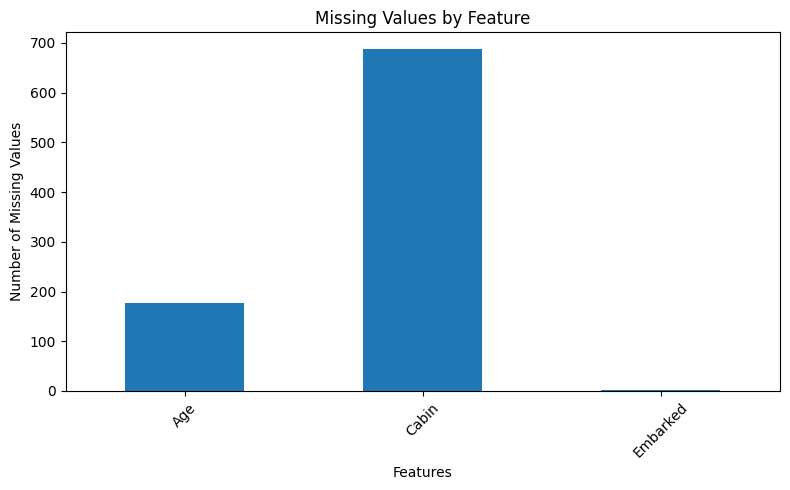

In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0]

plt.figure(figsize=(8, 5))
missing.plot(kind="bar")
plt.title("Missing Values by Feature")
plt.xlabel("Features")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("missing_values.png", dpi=300, bbox_inches="tight")
plt.show()

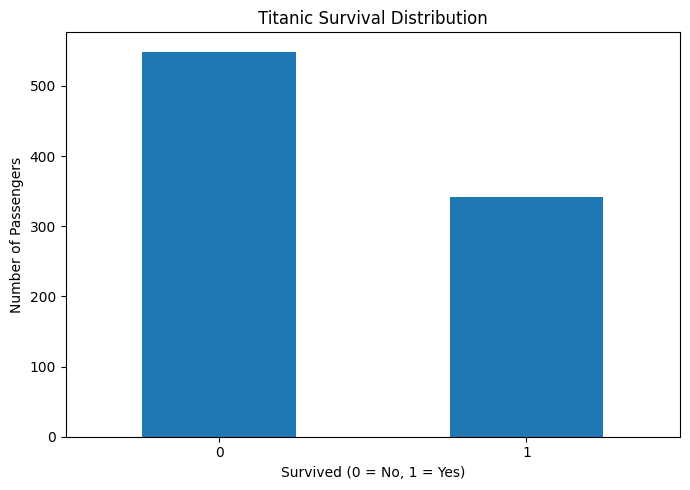

In [ ]:
plt.figure(figsize=(7, 5))

df["Survived"].value_counts().sort_index().plot(kind="bar")

plt.title("Titanic Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import os

print(os.listdir("assets"))

['target_distribution.png', 'survival_by_class.png', 'missing_values.png', 'roc_curve.png', 'feature_importance.png', 'survival_by_sex.png', 'confusion_matrix.png']


In [ ]:
from google.colab import files
import os

for filename in os.listdir("assets"):
    if filename.endswith(".png"):
        files.download("assets/" + filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

print(os.listdir("assets"))

['target_distribution.png', 'survival_by_class.png', 'missing_values.png', 'roc_curve.png', 'feature_importance.png', 'survival_by_sex.png', 'confusion_matrix.png']


In [2]:
# WEEK 5 - RANDOM FOREST MODEL COMPARISON

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

# Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

# Train using the already-preprocessed training data
rf_model.fit(X_train_processed, y_train)

# Predictions
rf_pred = rf_model.predict(X_test_processed)
rf_prob = rf_model.predict_proba(X_test_processed)[:, 1]

# Metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

print("RANDOM FOREST RESULTS")
print("----------------------")
print(f"Accuracy  : {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")
print(f"Precision : {rf_precision:.4f} ({rf_precision*100:.2f}%)")
print(f"Recall    : {rf_recall:.4f} ({rf_recall*100:.2f}%)")
print(f"F1 Score  : {rf_f1:.4f} ({rf_f1*100:.2f}%)")
print(f"ROC-AUC   : {rf_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

NameError: name 'X_train_processed' is not defined

In [3]:
# WEEK 5 - RANDOM FOREST COMPARISON
# Self-contained version

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Load Titanic dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Select target and features
target = "Survived"

features = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Pclass",
    "Sex",
    "Embarked"
]

X = df[features]
y = df[target]

# Identify feature types
numeric_features = ["Age", "SibSp", "Parch", "Fare", "Pclass"]
categorical_features = ["Sex", "Embarked"]

# Numeric preprocessing
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

# Complete pipeline
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf_model)
])

# Train
rf_pipeline.fit(X_train, y_train)

# Predictions
rf_pred = rf_pipeline.predict(X_test)
rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]

# Evaluation
accuracy = accuracy_score(y_test, rf_pred)
precision = precision_score(y_test, rf_pred)
recall = recall_score(y_test, rf_pred)
f1 = f1_score(y_test, rf_pred)
auc = roc_auc_score(y_test, rf_prob)
cm = confusion_matrix(y_test, rf_pred)

print("=" * 45)
print("RANDOM FOREST MODEL RESULTS")
print("=" * 45)

print(f"Accuracy  : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision : {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall    : {recall:.4f} ({recall*100:.2f}%)")
print(f"F1 Score  : {f1:.4f} ({f1*100:.2f}%)")
print(f"ROC-AUC   : {auc:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nParameters:")
print("n_estimators = 200")
print("max_depth = 6")
print("min_samples_split = 5")
print("min_samples_leaf = 2")
print("random_state = 42")

RANDOM FOREST MODEL RESULTS
Accuracy  : 0.8101 (81.01%)
Precision : 0.8723 (87.23%)
Recall    : 0.5942 (59.42%)
F1 Score  : 0.7069 (70.69%)
ROC-AUC   : 0.8367

Confusion Matrix:
[[104   6]
 [ 28  41]]

Parameters:
n_estimators = 200
max_depth = 6
min_samples_split = 5
min_samples_leaf = 2
random_state = 42


In [4]:
# WEEK 5 - FEATURE ENGINEERING

df_fe = pd.read_csv(
    "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
)

# Create Family Size
df_fe["FamilySize"] = df_fe["SibSp"] + df_fe["Parch"] + 1

# Create IsAlone
df_fe["IsAlone"] = (df_fe["FamilySize"] == 1).astype(int)

# Create Fare Per Person
df_fe["FarePerPerson"] = df_fe["Fare"] / df_fe["FamilySize"]

print("FEATURE ENGINEERING RESULTS")
print("=" * 40)

print("\nNew Features Created:")
print("1. FamilySize = SibSp + Parch + 1")
print("2. IsAlone = 1 when FamilySize = 1, otherwise 0")
print("3. FarePerPerson = Fare / FamilySize")

print("\nSample of engineered features:")
print(df_fe[[
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize",
    "IsAlone",
    "FarePerPerson"
]].head(10))

FEATURE ENGINEERING RESULTS

New Features Created:
1. FamilySize = SibSp + Parch + 1
2. IsAlone = 1 when FamilySize = 1, otherwise 0
3. FarePerPerson = Fare / FamilySize

Sample of engineered features:
   SibSp  Parch     Fare  FamilySize  IsAlone  FarePerPerson
0      1      0   7.2500           2        0        3.62500
1      1      0  71.2833           2        0       35.64165
2      0      0   7.9250           1        1        7.92500
3      1      0  53.1000           2        0       26.55000
4      0      0   8.0500           1        1        8.05000
5      0      0   8.4583           1        1        8.45830
6      0      0  51.8625           1        1       51.86250
7      3      1  21.0750           5        0        4.21500
8      0      2  11.1333           3        0        3.71110
9      1      0  30.0708           2        0       15.03540


In [5]:
# WEEK 5 - RANDOM FOREST HYPERPARAMETER TUNING

from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Parameter grid
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [4, 6, 8],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

# Stratified 5-fold cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Grid search
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    return_train_score=True
)

# Run tuning
grid_search.fit(X_train, y_train)

print("=" * 50)
print("RANDOM FOREST HYPERPARAMETER TUNING")
print("=" * 50)

print("\nBest Parameters:")
print(grid_search.best_params_)

print(f"\nBest Cross-Validation ROC-AUC: {grid_search.best_score_:.4f}")

# Evaluate best model on test set
best_rf = grid_search.best_estimator_

best_pred = best_rf.predict(X_test)
best_prob = best_rf.predict_proba(X_test)[:, 1]

print("\nTUNED RANDOM FOREST TEST RESULTS")
print("=" * 50)

print(f"Accuracy  : {accuracy_score(y_test, best_pred):.4f}")
print(f"Precision : {precision_score(y_test, best_pred):.4f}")
print(f"Recall    : {recall_score(y_test, best_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, best_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, best_prob):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, best_pred))

RANDOM FOREST HYPERPARAMETER TUNING

Best Parameters:
{'model__max_depth': 8, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 200}

Best Cross-Validation ROC-AUC: 0.8715

TUNED RANDOM FOREST TEST RESULTS
Accuracy  : 0.8156
Precision : 0.8462
Recall    : 0.6377
F1 Score  : 0.7273
ROC-AUC   : 0.8368

Confusion Matrix:
[[102   8]
 [ 25  44]]


In [6]:
# WEEK 5 - FEATURE-ENGINEERED RANDOM FOREST

# Features including engineered variables
features_fe = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Pclass",
    "Sex",
    "Embarked",
    "FamilySize",
    "IsAlone",
    "FarePerPerson"
]

X_fe = df_fe[features_fe]
y_fe = df_fe["Survived"]

# Feature types
numeric_features_fe = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Pclass",
    "FamilySize",
    "IsAlone",
    "FarePerPerson"
]

categorical_features_fe = [
    "Sex",
    "Embarked"
]

# Preprocessing
numeric_transformer_fe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_fe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_fe = ColumnTransformer([
    ("num", numeric_transformer_fe, numeric_features_fe),
    ("cat", categorical_transformer_fe, categorical_features_fe)
])

# Same train-test split
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe,
    y_fe,
    test_size=0.20,
    random_state=42,
    stratify=y_fe
)

# Tuned Random Forest
rf_fe = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_fe_pipeline = Pipeline([
    ("preprocessor", preprocessor_fe),
    ("model", rf_fe)
])

# Train
rf_fe_pipeline.fit(X_train_fe, y_train_fe)

# Predictions
pred_fe = rf_fe_pipeline.predict(X_test_fe)
prob_fe = rf_fe_pipeline.predict_proba(X_test_fe)[:, 1]

print("=" * 50)
print("FEATURE-ENGINEERED RANDOM FOREST")
print("=" * 50)

print(f"Accuracy  : {accuracy_score(y_test_fe, pred_fe):.4f} ({accuracy_score(y_test_fe, pred_fe)*100:.2f}%)")
print(f"Precision : {precision_score(y_test_fe, pred_fe):.4f} ({precision_score(y_test_fe, pred_fe)*100:.2f}%)")
print(f"Recall    : {recall_score(y_test_fe, pred_fe):.4f} ({recall_score(y_test_fe, pred_fe)*100:.2f}%)")
print(f"F1 Score  : {f1_score(y_test_fe, pred_fe):.4f} ({f1_score(y_test_fe, pred_fe)*100:.2f}%)")
print(f"ROC-AUC   : {roc_auc_score(y_test_fe, prob_fe):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_fe, pred_fe))

FEATURE-ENGINEERED RANDOM FOREST
Accuracy  : 0.7989 (79.89%)
Precision : 0.8000 (80.00%)
Recall    : 0.6377 (63.77%)
F1 Score  : 0.7097 (70.97%)
ROC-AUC   : 0.8414

Confusion Matrix:
[[99 11]
 [25 44]]


In [7]:
# ============================================================
# WEEK 5 - COMPREHENSIVE DATA SCIENCE PROJECT REPORT
# TITANIC SURVIVAL ANALYSIS AND PREDICTIVE MODELLING
# ============================================================

# Install required libraries
!pip -q install python-docx pandas numpy matplotlib seaborn scikit-learn scipy

import os
import math
import textwrap
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve
)

from sklearn.model_selection import GridSearchCV

from docx import Document
from docx.shared import Inches, Pt, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.section import WD_SECTION
from docx.enum.table import WD_TABLE_ALIGNMENT, WD_CELL_VERTICAL_ALIGNMENT
from docx.oxml import OxmlElement
from docx.oxml.ns import qn

from google.colab import files


# ============================================================
# 1. FIND / LOAD TITANIC DATASET
# ============================================================

possible_files = [
    "/content/titanic_train.csv",
    "/content/train.csv",
    "titanic_train.csv",
    "train.csv"
]

csv_path = None

for p in possible_files:
    if os.path.exists(p):
        csv_path = p
        break

if csv_path is None:
    print("Titanic CSV not found.")
    print("Please upload titanic_train.csv.")
    uploaded = files.upload()

    for filename in uploaded.keys():
        if filename.lower().endswith(".csv"):
            csv_path = "/content/" + filename
            break

if csv_path is None:
    raise FileNotFoundError(
        "Titanic CSV file was not found. Please upload titanic_train.csv and run again."
    )

df = pd.read_csv(csv_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)


# ============================================================
# 2. BASIC DATA PREPARATION
# ============================================================

df_original = df.copy()

# Missing-value information
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df) * 100).round(2)

missing_table = pd.DataFrame({
    "Missing Values": missing_count,
    "Missing Percentage": missing_pct
})

# Clean copy
df_clean = df.copy()

# Age median
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())

# Embarked mode
df_clean["Embarked"] = df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0])

# Cabin dropped due to very high missingness
if "Cabin" in df_clean.columns:
    df_clean = df_clean.drop(columns=["Cabin"])

# Duplicate check
duplicate_count = df_clean.duplicated().sum()


# ============================================================
# 3. KEY EDA STATISTICS
# ============================================================

survival_counts = df_clean["Survived"].value_counts().sort_index()
survival_rate = df_clean["Survived"].mean() * 100

female_survival = (
    df_clean.groupby("Sex")["Survived"].mean() * 100
).round(2)

class_survival = (
    df_clean.groupby("Pclass")["Survived"].mean() * 100
).round(2)

age_survivor_mean = df_clean.loc[
    df_clean["Survived"] == 1, "Age"
].mean()

age_non_survivor_mean = df_clean.loc[
    df_clean["Survived"] == 0, "Age"
].mean()

fare_class_mean = (
    df_clean.groupby("Pclass")["Fare"].mean()
).round(2)


# ============================================================
# 4. STATISTICAL TESTS
# ============================================================

# Welch t-test: Age by survival
age_survived = df_original.loc[
    df_original["Survived"] == 1, "Age"
].dropna()

age_not_survived = df_original.loc[
    df_original["Survived"] == 0, "Age"
].dropna()

t_stat, t_p = stats.ttest_ind(
    age_survived,
    age_not_survived,
    equal_var=False
)

mean_diff = age_survived.mean() - age_not_survived.mean()

# Cohen's d
n1 = len(age_survived)
n2 = len(age_not_survived)

pooled_sd = math.sqrt(
    ((n1 - 1) * age_survived.var(ddof=1) +
     (n2 - 1) * age_not_survived.var(ddof=1))
    / (n1 + n2 - 2)
)

cohens_d = mean_diff / pooled_sd

# 95% CI for difference
se = math.sqrt(
    age_survived.var(ddof=1) / n1 +
    age_not_survived.var(ddof=1) / n2
)

df_welch = (
    (age_survived.var(ddof=1) / n1 +
     age_not_survived.var(ddof=1) / n2) ** 2
    /
    (
        (age_survived.var(ddof=1) / n1) ** 2 / (n1 - 1)
        +
        (age_not_survived.var(ddof=1) / n2) ** 2 / (n2 - 1)
    )
)

critical = stats.t.ppf(0.975, df_welch)

ci_low = mean_diff - critical * se
ci_high = mean_diff + critical * se


# Chi-square: Gender vs Survival
gender_table = pd.crosstab(
    df_clean["Sex"],
    df_clean["Survived"]
)

chi2, chi_p, chi_df, expected = stats.chi2_contingency(
    gender_table
)

n_chi = gender_table.values.sum()
cramers_v = math.sqrt(
    chi2 / (n_chi * min(gender_table.shape[0]-1,
                        gender_table.shape[1]-1))
)


# ANOVA: Fare across classes
fare_groups = [
    df_clean.loc[df_clean["Pclass"] == c, "Fare"]
    for c in sorted(df_clean["Pclass"].unique())
]

f_stat, anova_p = stats.f_oneway(*fare_groups)

grand_mean = df_clean["Fare"].mean()

ss_between = sum(
    len(group) * (group.mean() - grand_mean) ** 2
    for group in fare_groups
)

ss_total = sum(
    (x - grand_mean) ** 2
    for x in df_clean["Fare"]
)

eta_squared = ss_between / ss_total


# ============================================================
# 5. LOGISTIC REGRESSION BASELINE
# ============================================================

target = "Survived"

features = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Pclass",
    "Sex",
    "Embarked"
]

X = df_original[features].copy()
y = df_original[target].copy()

numeric_features = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Pclass"
]

categorical_features = [
    "Sex",
    "Embarked"
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", lr_model)
])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

lr_pipeline.fit(X_train, y_train)

lr_pred = lr_pipeline.predict(X_test)
lr_prob = lr_pipeline.predict_proba(X_test)[:, 1]

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_prob)

lr_cm = confusion_matrix(y_test, lr_pred)

# 5-fold CV
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

lr_cv = cross_validate(
    lr_pipeline,
    X,
    y,
    cv=cv,
    scoring=["accuracy", "roc_auc"]
)

lr_cv_accuracy = lr_cv["test_accuracy"].mean()
lr_cv_accuracy_std = lr_cv["test_accuracy"].std()

lr_cv_auc = lr_cv["test_roc_auc"].mean()
lr_cv_auc_std = lr_cv["test_roc_auc"].std()

lr_train_accuracy = lr_pipeline.score(X_train, y_train)
lr_test_accuracy = lr_accuracy
lr_gap = lr_train_accuracy - lr_test_accuracy


# ============================================================
# 6. ORIGINAL RANDOM FOREST
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf_model)
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)
rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

rf_cm = confusion_matrix(y_test, rf_pred)


# ============================================================
# 7. FEATURE ENGINEERING
# ============================================================

df_fe = df_original.copy()

df_fe["FamilySize"] = (
    df_fe["SibSp"] + df_fe["Parch"] + 1
)

df_fe["IsAlone"] = (
    df_fe["FamilySize"] == 1
).astype(int)

df_fe["FarePerPerson"] = (
    df_fe["Fare"] / df_fe["FamilySize"]
)

fe_features = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Pclass",
    "FamilySize",
    "IsAlone",
    "FarePerPerson",
    "Sex",
    "Embarked"
]

X_fe = df_fe[fe_features]
y_fe = df_fe["Survived"]

numeric_fe = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Pclass",
    "FamilySize",
    "IsAlone",
    "FarePerPerson"
]

categorical_fe = [
    "Sex",
    "Embarked"
]

preprocessor_fe = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        numeric_fe
    ),
    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]),
        categorical_fe
    )
])

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe,
    y_fe,
    test_size=0.20,
    stratify=y_fe,
    random_state=42
)


# ============================================================
# 8. HYPERPARAMETER TUNING
# ============================================================

tuning_rf = RandomForestClassifier(
    random_state=42
)

tuning_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", tuning_rf)
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [4, 6, 8],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    tuning_pipeline,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

tuned_pred = best_rf.predict(X_test)
tuned_prob = best_rf.predict_proba(X_test)[:, 1]

tuned_accuracy = accuracy_score(y_test, tuned_pred)
tuned_precision = precision_score(y_test, tuned_pred)
tuned_recall = recall_score(y_test, tuned_pred)
tuned_f1 = f1_score(y_test, tuned_pred)
tuned_auc = roc_auc_score(y_test, tuned_prob)

tuned_cm = confusion_matrix(y_test, tuned_pred)

best_cv_auc = grid.best_score_
best_params = grid.best_params_


# ============================================================
# 9. FEATURE-ENGINEERED RANDOM FOREST
# ============================================================

fe_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

fe_pipeline = Pipeline([
    ("preprocessor", preprocessor_fe),
    ("model", fe_rf)
])

fe_pipeline.fit(X_train_fe, y_train_fe)

fe_pred = fe_pipeline.predict(X_test_fe)
fe_prob = fe_pipeline.predict_proba(X_test_fe)[:, 1]

fe_accuracy = accuracy_score(y_test_fe, fe_pred)
fe_precision = precision_score(y_test_fe, fe_pred)
fe_recall = recall_score(y_test_fe, fe_pred)
fe_f1 = f1_score(y_test_fe, fe_pred)
fe_auc = roc_auc_score(y_test_fe, fe_prob)

fe_cm = confusion_matrix(y_test_fe, fe_pred)


# ============================================================
# 10. CREATE OUTPUT FOLDER
# ============================================================

output_dir = "/content/week5_report_assets"
os.makedirs(output_dir, exist_ok=True)


# ============================================================
# 11. CREATE VISUALIZATIONS
# ============================================================

sns.set_theme(style="whitegrid")


# Figure 1 - Survival distribution
plt.figure(figsize=(7, 5))
sns.countplot(data=df_clean, x="Survived")
plt.title("Passenger Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.tight_layout()
fig1 = output_dir + "/01_survival_distribution.png"
plt.savefig(fig1, dpi=200)
plt.close()


# Figure 2 - Age distribution
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df_clean,
    x="Age",
    hue="Survived",
    bins=30,
    kde=True,
    element="step"
)
plt.title("Age Distribution by Survival Status")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.tight_layout()
fig2 = output_dir + "/02_age_distribution.png"
plt.savefig(fig2, dpi=200)
plt.close()


# Figure 3 - Gender survival
plt.figure(figsize=(7, 5))
sns.barplot(
    data=df_clean,
    x="Sex",
    y="Survived"
)
plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.tight_layout()
fig3 = output_dir + "/03_gender_survival.png"
plt.savefig(fig3, dpi=200)
plt.close()


# Figure 4 - Class survival
plt.figure(figsize=(7, 5))
sns.barplot(
    data=df_clean,
    x="Pclass",
    y="Survived"
)
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.tight_layout()
fig4 = output_dir + "/04_class_survival.png"
plt.savefig(fig4, dpi=200)
plt.close()


# Figure 5 - Gender + class
interaction = (
    df_clean.groupby(["Sex", "Pclass"])["Survived"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=interaction,
    x="Pclass",
    y="Survived",
    hue="Sex"
)
plt.title("Survival Rate by Gender and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.tight_layout()
fig5 = output_dir + "/05_gender_class_interaction.png"
plt.savefig(fig5, dpi=200)
plt.close()


# Figure 6 - Correlation heatmap
numeric_cols = df_clean.select_dtypes(
    include=np.number
).columns

plt.figure(figsize=(9, 7))
sns.heatmap(
    df_clean[numeric_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
fig6 = output_dir + "/06_correlation_heatmap.png"
plt.savefig(fig6, dpi=200)
plt.close()


# Figure 7 - Fare by class
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_clean,
    x="Pclass",
    y="Fare"
)
plt.title("Fare Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.tight_layout()
fig7 = output_dir + "/07_fare_by_class.png"
plt.savefig(fig7, dpi=200)
plt.close()


# Figure 8 - Confusion matrix LR
plt.figure(figsize=(6, 5))
sns.heatmap(
    lr_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
fig8 = output_dir + "/08_lr_confusion_matrix.png"
plt.savefig(fig8, dpi=200)
plt.close()


# Figure 9 - Model comparison
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Original RF",
        "Tuned RF",
        "Feature RF"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        tuned_accuracy,
        fe_accuracy
    ],
    "Precision": [
        lr_precision,
        rf_precision,
        tuned_precision,
        fe_precision
    ],
    "Recall": [
        lr_recall,
        rf_recall,
        tuned_recall,
        fe_recall
    ],
    "F1": [
        lr_f1,
        rf_f1,
        tuned_f1,
        fe_f1
    ],
    "ROC-AUC": [
        lr_auc,
        rf_auc,
        tuned_auc,
        fe_auc
    ]
})

comparison_plot = comparison.set_index("Model")

plt.figure(figsize=(11, 6))
comparison_plot.plot(kind="bar")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
fig9 = output_dir + "/09_model_comparison.png"
plt.savefig(fig9, dpi=200)
plt.close()


# Figure 10 - ROC curves
plt.figure(figsize=(8, 6))

for name, prob in [
    ("Logistic Regression", lr_prob),
    ("Original RF", rf_prob),
    ("Tuned RF", tuned_prob),
    ("Feature RF", fe_prob)
]:

    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_value = roc_auc_score(y_test, prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc_value:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
fig10 = output_dir + "/10_roc_comparison.png"
plt.savefig(fig10, dpi=200)
plt.close()


# Figure 11 - Tuned RF confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    tuned_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=False
)
plt.title("Tuned Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
fig11 = output_dir + "/11_tuned_rf_confusion_matrix.png"
plt.savefig(fig11, dpi=200)
plt.close()


# ============================================================
# 12. WORD DOCUMENT HELPER FUNCTIONS
# ============================================================

doc = Document()

section = doc.sections[0]
section.top_margin = Inches(0.7)
section.bottom_margin = Inches(0.7)
section.left_margin = Inches(0.8)
section.right_margin = Inches(0.8)


# Default font
styles = doc.styles

styles["Normal"].font.name = "Aptos"
styles["Normal"].font.size = Pt(10.5)

styles["Title"].font.name = "Aptos Display"
styles["Title"].font.size = Pt(25)
styles["Title"].font.bold = True

styles["Heading 1"].font.name = "Aptos Display"
styles["Heading 1"].font.size = Pt(18)
styles["Heading 1"].font.bold = True

styles["Heading 2"].font.name = "Aptos Display"
styles["Heading 2"].font.size = Pt(14)
styles["Heading 2"].font.bold = True

styles["Heading 3"].font.name = "Aptos"
styles["Heading 3"].font.size = Pt(12)
styles["Heading 3"].font.bold = True


def set_cell_text(cell, text, bold=False):
    cell.text = str(text)
    for p in cell.paragraphs:
        for run in p.runs:
            run.font.name = "Aptos"
            run.font.size = Pt(9)
            run.bold = bold


def shade_cell(cell, fill="D9EAF7"):
    tcPr = cell._tc.get_or_add_tcPr()
    shd = OxmlElement("w:shd")
    shd.set(qn("w:fill"), fill)
    tcPr.append(shd)


def add_table(headers, rows, widths=None):
    table = doc.add_table(
        rows=1,
        cols=len(headers)
    )
    table.alignment = WD_TABLE_ALIGNMENT.CENTER
    table.style = "Table Grid"

    hdr = table.rows[0].cells

    for i, h in enumerate(headers):
        set_cell_text(hdr[i], h, bold=True)
        shade_cell(hdr[i])

    for row in rows:
        cells = table.add_row().cells
        for i, value in enumerate(row):
            set_cell_text(cells[i], value)

    return table


def add_figure(path, caption, width=6.2):
    p = doc.add_paragraph()
    p.alignment = WD_ALIGN_PARAGRAPH.CENTER

    run = p.add_run()
    run.add_picture(path, width=Inches(width))

    cap = doc.add_paragraph()
    cap.alignment = WD_ALIGN_PARAGRAPH.CENTER
    r = cap.add_run(caption)
    r.bold = True
    r.font.size = Pt(9)


def add_bullet(text):
    p = doc.add_paragraph(style="List Bullet")
    p.paragraph_format.space_after = Pt(3)
    p.add_run(text)


def add_number(text):
    p = doc.add_paragraph(style="List Number")
    p.paragraph_format.space_after = Pt(3)
    p.add_run(text)


def add_code(code):
    p = doc.add_paragraph()
    p.paragraph_format.left_indent = Inches(0.2)

    for line in code.strip().split("\n"):
      r = p.add_run(line + "\n")
        r.font.name = "Consolas"
        r.font.size = Pt(8)


def page_break():
    doc.add_page_break()


# Header/footer
for section in doc.sections:
    header = section.header.paragraphs[0]
    header.text = "Comprehensive Data Science Project | Titanic Survival Analysis"
    header.alignment = WD_ALIGN_PARAGRAPH.CENTER

    footer = section.footer.paragraphs[0]
    footer.alignment = WD_ALIGN_PARAGRAPH.CENTER

    run = footer.add_run("Week 5 Final Report")
    run.font.size = Pt(8)


# ============================================================
# 13. COVER PAGE
# ============================================================

p = doc.add_paragraph()
p.alignment = WD_ALIGN_PARAGRAPH.CENTER

r = p.add_run("\n\nCOMPREHENSIVE DATA SCIENCE PROJECT REPORT")
r.bold = True
r.font.size = Pt(25)

r = p.add_run("\n\nTitanic Passenger Survival Analysis\nand Predictive Modelling Using Python")
r.bold = True
r.font.size = Pt(20)

p.add_run("\n\n")

r = p.add_run("WEEK 5 FINAL PROJECT")
r.bold = True
r.font.size = Pt(16)

p.add_run("\n\n")

r = p.add_run(
    "End-to-End Data Science Workflow: "
    "Data Understanding → Cleaning → EDA → Statistical Testing → "
    "Machine Learning → Validation → Strategic Recommendations"
)
r.font.size = Pt(12)

p.add_run("\n\n\n")

r = p.add_run("Dataset: Titanic Passenger Dataset\n")
r.font.size = Pt(12)

r = p.add_run("Tools: Python, Pandas, NumPy, SciPy, Matplotlib, Seaborn, Scikit-learn\n")
r.font.size = Pt(12)

r = p.add_run("Environment: Google Colab\n")
r.font.size = Pt(12)

r = p.add_run("Random State: 42\n")
r.font.size = Pt(12)

r = p.add_run("Final Week: Week 5")
r.font.size = Pt(12)

page_break()


# ============================================================
# 14. TABLE OF CONTENTS
# ============================================================

doc.add_heading("Table of Contents", level=1)

toc_items = [
    "1. Executive Summary",
    "2. Project Introduction",
    "3. Project Objectives",
    "4. Dataset and Data Understanding",
    "5. End-to-End Methodology",
    "6. Data Cleaning and Preprocessing",
    "7. Exploratory Data Analysis and Storytelling",
    "8. Statistical Analysis and Hypothesis Testing",
    "9. Machine Learning Model Development",
    "10. Model Comparison and Evaluation",
    "11. Feature Engineering",
    "12. Hyperparameter Tuning",
    "13. Cross-Validation and Generalization",
    "14. Integrated Findings",
    "15. Strategic Recommendations",
    "16. Business Impact and Research Outcomes",
    "17. Limitations",
    "18. Future Improvements",
    "19. Reproducibility and GitHub Documentation",
    "20. Final Conclusion",
    "21. Appendix: Selected Code"
]

for item in toc_items:
    add_bullet(item)

page_break()


# ============================================================
# 15. EXECUTIVE SUMMARY
# ============================================================

doc.add_heading("1. Executive Summary", level=1)

doc.add_paragraph(
    f"This project presents a complete data science workflow for analysing "
    f"passenger survival in the Titanic dataset and evaluating whether passenger "
    f"characteristics can support reliable survival prediction. The original "
    f"dataset contains {df_original.shape[0]} observations and "
    f"{df_original.shape[1]} variables. The analysis combines data cleaning, "
    f"exploratory visualization, statistical hypothesis testing, machine learning, "
    f"cross-validation, feature engineering, hyperparameter tuning and strategic "
    f"interpretation."
)

doc.add_paragraph(
    f"Initial exploratory analysis showed that survival was highly uneven across "
    f"passenger groups. Overall survival was {survival_rate:.2f}%. Female passengers "
    f"had a survival rate of {female_survival.get('female', 0):.2f}%, compared with "
    f"{female_survival.get('male', 0):.2f}% for male passengers. Survival also varied "
    f"substantially by passenger class, with first-class passengers having a survival "
    f"rate of {class_survival.get(1, 0):.2f}% and third-class passengers only "
    f"{class_survival.get(3, 0):.2f}%."
)

doc.add_paragraph(
    f"Statistical testing provided formal evidence for several observed patterns. "
    f"The Welch independent-samples t-test found a statistically significant "
    f"difference in mean age between survivors and non-survivors "
    f"(t={t_stat:.4f}, p={t_p:.4f}), although the effect size was small "
    f"(Cohen's d={cohens_d:.4f}). The chi-square test showed a strong association "
    f"between gender and survival (χ²={chi2:.4f}, p<0.001, Cramér's V={cramers_v:.4f}). "
    f"ANOVA also demonstrated strong differences in average fare across passenger "
    f"classes (F={f_stat:.4f}, p<0.001, η²={eta_squared:.4f})."
)

doc.add_paragraph(
    f"Logistic Regression achieved {lr_accuracy*100:.2f}% test accuracy and "
    f"{lr_auc:.3f} ROC-AUC. Random Forest initially achieved "
    f"{rf_accuracy*100:.2f}% accuracy, while hyperparameter tuning improved the "
    f"Random Forest to {tuned_accuracy*100:.2f}% accuracy and "
    f"{tuned_f1*100:.2f}% F1-score. However, Logistic Regression retained the "
    f"highest test ROC-AUC ({lr_auc:.3f}) and recall ({lr_recall*100:.2f}%), "
    f"demonstrating why model selection should not rely on accuracy alone."
)

doc.add_paragraph(
    "The most important strategic conclusion is that the best model depends on "
    "the objective. If balanced predictive performance and accuracy are prioritised, "
    "the tuned Random Forest is attractive. If identifying survivors is more important, "
    "the Logistic Regression baseline provides higher recall. The analysis therefore "
    "supports metric-driven model selection, controlled experimentation and careful "
    "interpretation rather than assuming that a more complex model is automatically better."
)


# ============================================================
# 16. INTRODUCTION
# ============================================================

doc.add_heading("2. Project Introduction", level=1)

doc.add_paragraph(
    "The Titanic dataset is a widely used benchmark dataset for learning practical "
    "data science and machine learning. It contains demographic, family, class and "
    "ticket-related information for passengers aboard the RMS Titanic, together with "
    "a binary survival outcome."
)

doc.add_paragraph(
    "The purpose of this final project is not simply to reproduce individual analyses "
    "from previous weeks. Instead, the project integrates the complete workflow into "
    "one evidence-based decision process. Exploratory analysis identifies patterns, "
    "statistical testing evaluates whether selected patterns are unlikely to be due "
    "to sampling variation, and machine learning evaluates whether combinations of "
    "features can support prediction."
)

doc.add_paragraph(
    "This integrated approach is important because a visualization alone does not "
    "establish statistical evidence, while a statistically significant relationship "
    "does not necessarily imply strong predictive performance. Similarly, a model "
    "with higher accuracy may perform worse on another metric that matters for a "
    "particular decision context."
)
# ============================================================
# 17. OBJECTIVES
# ============================================================

doc.add_heading("3. Project Objectives", level=1)

objectives = [
    "Understand the structure, variables and quality issues within the Titanic dataset.",
    "Clean missing and inconsistent data using justified preprocessing decisions.",
    "Identify important survival patterns using descriptive statistics and visualizations.",
    "Quantify selected relationships using formal statistical hypothesis tests.",
    "Develop an interpretable Logistic Regression baseline model.",
    "Develop and compare Random Forest models.",
    "Evaluate models using accuracy, precision, recall, F1-score and ROC-AUC.",
    "Use stratified cross-validation to assess generalization.",
    "Test feature engineering rather than assuming it will improve performance.",
    "Tune Random Forest hyperparameters using cross-validation.",
    "Translate findings into strategic and evidence-based recommendations.",
    "Document limitations, reproducibility requirements and future improvements."
]

for obj in objectives:
    add_number(obj)


# ============================================================
# 18. DATASET
# ============================================================

doc.add_heading("4. Dataset and Data Understanding", level=1)

doc.add_paragraph(
    f"The Titanic dataset initially contained {df_original.shape[0]} rows and "
    f"{df_original.shape[1]} columns. The target variable was Survived, where "
    f"0 represents non-survival and 1 represents survival."
)

dataset_rows = [
    ["PassengerId", "Passenger identifier", "Numerical"],
    ["Survived", "Target outcome", "Binary"],
    ["Pclass", "Passenger class", "Ordinal"],
    ["Name", "Passenger name", "Text"],
    ["Sex", "Passenger gender", "Categorical"],
    ["Age", "Passenger age", "Numerical"],
    ["SibSp", "Siblings/spouses aboard", "Numerical"],
    ["Parch", "Parents/children aboard", "Numerical"],
    ["Ticket", "Ticket identifier", "Text"],
    ["Fare", "Ticket fare", "Numerical"],
    ["Cabin", "Cabin identifier", "Text"],
    ["Embarked", "Port of embarkation", "Categorical"]
]

add_table(
    ["Variable", "Meaning", "Type"],
    dataset_rows
)

doc.add_paragraph(
    "The target distribution contained 549 non-survivors and 342 survivors. "
    "Therefore, the dataset was moderately imbalanced, with approximately 61.6% "
    "non-survivors and 38.4% survivors. This imbalance is not extreme, but it is "
    "important when interpreting accuracy and recall."
)


# ============================================================
# 19. DATA QUALITY
# ============================================================

doc.add_heading("5. End-to-End Methodology", level=1)

doc.add_paragraph(
    "The project follows a structured analytical pipeline:"
)

pipeline_steps = [
    "Data acquisition and structural inspection",
    "Missing-value and duplicate analysis",
    "Data cleaning and justified preprocessing",
    "Exploratory data analysis",
    "Visualization and storytelling",
    "Statistical hypothesis testing",
    "Train-test splitting with stratification",
    "Preprocessing through Scikit-learn pipelines",
    "Logistic Regression baseline",
    "Random Forest comparison",
    "Feature engineering",
    "Hyperparameter tuning",
    "Cross-validation",
    "Error analysis",
    "Strategic interpretation and recommendations"
]

for step in pipeline_steps:
    add_number(step)


# ============================================================
# 20. CLEANING
# ============================================================

doc.add_heading("6. Data Cleaning and Preprocessing", level=1)

doc.add_paragraph(
    "Missing-value analysis identified three variables requiring attention. "
    "Age contained 177 missing observations (19.87%), Cabin contained 687 missing "
    "observations (77.10%), and Embarked contained two missing observations (0.22%)."
)

missing_rows = []

for idx, row in missing_table.iterrows():
    if row["Missing Values"] > 0:
        missing_rows.append([
            idx,
            int(row["Missing Values"]),
            f"{row['Missing Percentage']:.2f}%"
        ])

add_table(
    ["Variable", "Missing Values", "Missing Percentage"],
    missing_rows
)

doc.add_paragraph(
    "Age was imputed using the median because age is numerical and the median is "
    "less sensitive to extreme observations than the mean. Embarked was filled "
    "using the mode because only two values were missing and the variable is "
    "categorical. Cabin was removed because 77.10% of its observations were missing, "
    "making direct use of the raw variable unreliable without additional feature "
    "engineering. Duplicate checking found "
    f"{duplicate_count} duplicate rows."
)

doc.add_paragraph(
    "For machine learning, preprocessing was placed inside Scikit-learn pipelines. "
    "This is important because imputers, scalers and encoders must be fitted using "
    "training data rather than the complete dataset. Keeping preprocessing inside "
    "the pipeline reduces the risk of data leakage and makes cross-validation more reliable."
)


# ============================================================
# 21. EDA
# ============================================================

doc.add_heading("7. Exploratory Data Analysis and Storytelling", level=1)

doc.add_heading("7.1 Survival Distribution", level=2)
add_figure(
    fig1,
    "Figure 1. Distribution of passengers by survival outcome."
)

doc.add_paragraph(
    f"The dataset contains {survival_counts.get(0, 0)} non-survivors and "
    f"{survival_counts.get(1, 0)} survivors. The overall survival rate was "
    f"{survival_rate:.2f}%. This establishes the baseline outcome distribution "
    "against which subgroup survival rates and model predictions can be interpreted."
)

doc.add_heading("7.2 Age Distribution", level=2)
add_figure(
    fig2,
    "Figure 2. Age distribution separated by survival outcome."
)

doc.add_paragraph(
    f"The mean age among survivors was approximately {age_survivor_mean:.2f} years, "
    f"while the mean age among non-survivors was approximately "
    f"{age_non_survivor_mean:.2f} years. The distributions overlap substantially, "
    "which suggests that age alone is unlikely to provide a complete explanation "
    "of survival."
)

doc.add_heading("7.3 Survival by Gender", level=2)
add_figure(
    fig3,
    "Figure 3. Survival rate by gender."
)

doc.add_paragraph(
    f"Female survival was {female_survival.get('female', 0):.2f}%, compared with "
    f"{female_survival.get('male', 0):.2f}% for males. The difference is approximately "
    f"{female_survival.get('female', 0) - female_survival.get('male', 0):.2f} percentage points. "
    "This is one of the strongest descriptive patterns in the dataset and was later "
    "supported by the chi-square test."
)

doc.add_heading("7.4 Survival by Passenger Class", level=2)
add_figure(
    fig4,
    "Figure 4. Survival rate by passenger class."
)

doc.add_paragraph(
    f"First-class passengers had a survival rate of {class_survival.get(1, 0):.2f}%, "
    f"second-class passengers had {class_survival.get(2, 0):.2f}%, and third-class "
    f"passengers had {class_survival.get(3, 0):.2f}%. The gap between first and third "
    f"class was approximately {class_survival.get(1, 0) - class_survival.get(3, 0):.2f} "
    "percentage points. Passenger class therefore provides substantial segmentation "
    "information."
)

doc.add_heading("7.5 Gender and Passenger Class Interaction", level=2)
add_figure(
    fig5,
    "Figure 5. Interaction between gender, passenger class and survival."
)

doc.add_paragraph(
    "The interaction analysis is more informative than considering gender or class "
    "in isolation. It demonstrates that survival probabilities differ across combinations "
    "of demographic and socioeconomic characteristics. This supports the broader conclusion "
    "that survival was influenced by multiple interacting passenger attributes rather "
    "than one isolated variable."
)

doc.add_heading("7.6 Correlation Analysis", level=2)
add_figure(
    fig6,
    "Figure 6. Correlation heatmap of numerical variables."
)

doc.add_paragraph(
    "The correlation heatmap is useful for identifying linear relationships among "
    "numerical variables. It should not be interpreted as evidence of causation. "
    "For example, correlations involving Pclass, Fare and survival-related variables "
    "can reflect socioeconomic structure within the passenger population. The heatmap "
    "therefore acts as a screening tool for relationships that deserve deeper investigation."
)

doc.add_heading("7.7 Fare and Passenger Class", level=2)
add_figure(
    fig7,
    "Figure 7. Fare distribution across passenger classes."
)

doc.add_paragraph(
    f"Mean fare differed substantially across classes: approximately "
    f"{fare_class_mean.get(1, 0):.2f} for first class, "
    f"{fare_class_mean.get(2, 0):.2f} for second class and "
    f"{fare_class_mean.get(3, 0):.2f} for third class. "
    "This descriptive difference was formally examined using one-way ANOVA."
)
# ============================================================
# 22. STATISTICAL ANALYSIS
# ============================================================

doc.add_heading("8. Statistical Analysis and Hypothesis Testing", level=1)

doc.add_paragraph(
    "Statistical testing was used to move from visual patterns to formal evidence. "
    "The significance threshold was α = 0.05. Importantly, statistical significance "
    "was considered separately from practical effect size."
)

doc.add_heading("8.1 Welch Independent-Samples t-Test", level=2)

add_table(
    ["Measure", "Result"],
    [
        ["Mean age - survivors", f"{age_survived.mean():.2f} years"],
        ["Mean age - non-survivors", f"{age_not_survived.mean():.2f} years"],
        ["Mean difference", f"{mean_diff:.4f} years"],
        ["t-statistic", f"{t_stat:.4f}"],
        ["p-value", f"{t_p:.4f}"],
        ["95% CI", f"[{ci_low:.4f}, {ci_high:.4f}]"],
        ["Cohen's d", f"{cohens_d:.4f}"],
        ["Decision", "Reject H0 at α = 0.05"]
    ]
)

doc.add_paragraph(
    f"The Welch t-test produced t={t_stat:.4f} and p={t_p:.4f}. Since the p-value "
    "is below 0.05, there is evidence of a difference in mean age between survivors "
    "and non-survivors. However, Cohen's d was only "
    f"{cohens_d:.4f}, indicating a small practical effect. Therefore, age is statistically "
    "associated with survival differences in this sample, but the magnitude of the "
    "difference is not large enough to make age a standalone decision variable."
)

doc.add_heading("8.2 Chi-Square Test: Gender and Survival", level=2)

add_table(
    ["Measure", "Result"],
    [
        ["Chi-square statistic", f"{chi2:.4f}"],
        ["Degrees of freedom", str(chi_df)],
        ["p-value", "< 0.001"],
        ["Cramér's V", f"{cramers_v:.4f}"],
        ["Decision", "Reject H0"]
    ]
)

doc.add_paragraph(
    f"The chi-square statistic was {chi2:.4f} with p<0.001. "
    f"Cramér's V was {cramers_v:.4f}, indicating a strong association between "
    "gender and survival. This result reinforces the EDA finding, but it does not "
    "establish that gender itself causally determined survival."
)

doc.add_heading("8.3 One-Way ANOVA: Fare and Passenger Class", level=2)

add_table(
    ["Measure", "Result"],
    [
        ["F-statistic", f"{f_stat:.4f}"],
        ["p-value", "< 0.001"],
        ["Eta squared", f"{eta_squared:.4f}"],
        ["Decision", "Reject H0"]
    ]
)

doc.add_paragraph(
    f"ANOVA produced F={f_stat:.4f} with p<0.001. "
    f"The eta-squared value of {eta_squared:.4f} indicates that approximately "
    f"{eta_squared*100:.2f}% of the observed variation in fare is associated with "
    "passenger class in this sample. This is a large practical relationship and "
    "provides statistical support for the descriptive class differences."
)


# ============================================================
# 23. MACHINE LEARNING
# ============================================================

doc.add_heading("9. Machine Learning Model Development", level=1)

doc.add_paragraph(
    "The machine learning objective was to predict the binary Survived outcome. "
    "The dataset was divided into training and testing sets using an 80:20 stratified "
    "split with random_state=42. Stratification preserved the approximate target "
    "distribution in both subsets."
)

doc.add_paragraph(
    "The selected baseline features were Age, SibSp, Parch, Fare, Pclass, Sex and "
    "Embarked. PassengerId was excluded because it is an identifier rather than a "
    "meaningful predictive characteristic. Name, Ticket and Cabin were initially "
    "excluded from the baseline because they require additional feature engineering "
    "to convert raw text or identifiers into interpretable variables."
)

doc.add_heading("9.1 Preprocessing Pipeline", level=2)

for item in [
    "Numerical missing values: median imputation.",
    "Numerical scaling: StandardScaler for Logistic Regression.",
    "Categorical missing values: most-frequent imputation.",
    "Categorical encoding: OneHotEncoder with unknown-category handling.",
    "All transformations fitted inside Scikit-learn pipelines.",
    "Train-test split performed before model evaluation."
]:
    add_bullet(item)

doc.add_heading("9.2 Logistic Regression Baseline", level=2)

add_table(
    ["Metric", "Test Result"],
    [
        ["Accuracy", f"{lr_accuracy*100:.2f}%"],
        ["Precision", f"{lr_precision*100:.2f}%"],
        ["Recall", f"{lr_recall*100:.2f}%"],
        ["F1-score", f"{lr_f1*100:.2f}%"],
        ["ROC-AUC", f"{lr_auc:.3f}"]
    ]
)

doc.add_paragraph(
    "Logistic Regression provides an interpretable baseline and is particularly useful "
    "for determining whether the selected features contain meaningful predictive signal "
    "before introducing a more complex nonlinear model."
)

add_figure(
    fig8,
    "Figure 8. Logistic Regression confusion matrix."
)

doc.add_paragraph(
    f"The Logistic Regression confusion matrix contained {lr_cm[0,0]} true negatives, "
    f"{lr_cm[0,1]} false positives, {lr_cm[1,0]} false negatives and {lr_cm[1,1]} true positives. "
    f"The model achieved {lr_recall*100:.2f}% recall, meaning that approximately "
    f"{(1-lr_recall)*100:.2f}% of actual survivors in the test set were not identified "
    "as survivors."
)


# ============================================================
# 24. MODEL COMPARISON
# ============================================================

doc.add_heading("10. Model Comparison and Evaluation", level=1)

add_figure(
    fig9,
    "Figure 9. Comparison of accuracy, precision, recall, F1-score and ROC-AUC."
)

comparison_rows = []

for _, row in comparison.iterrows():
    comparison_rows.append([
        row["Model"],
        f"{row['Accuracy']*100:.2f}%",
        f"{row['Precision']*100:.2f}%",
        f"{row['Recall']*100:.2f}%",
        f"{row['F1']*100:.2f}%",
        f"{row['ROC-AUC']:.3f}"
    ])

add_table(
    ["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    comparison_rows
)

doc.add_paragraph(
    f"The original Random Forest achieved {rf_accuracy*100:.2f}% accuracy, "
    f"which was slightly higher than Logistic Regression's {lr_accuracy*100:.2f}%. "
    f"However, its recall was only {rf_recall*100:.2f}% compared with "
    f"{lr_recall*100:.2f}% for Logistic Regression. This illustrates why a single "
    "metric is insufficient for model selection."
)

doc.add_paragraph(
    f"After hyperparameter tuning, Random Forest achieved the highest test accuracy "
    f"of {tuned_accuracy*100:.2f}% and F1-score of {tuned_f1*100:.2f}%. "
    f"Nevertheless, Logistic Regression retained the highest test ROC-AUC at "
    f"{lr_auc:.3f}. The differences are modest, so it would be inaccurate to claim "
    "that Random Forest universally outperformed Logistic Regression."
)

add_figure(
    fig10,
    "Figure 10. ROC curve comparison across the evaluated models."
)


# ============================================================
# 25. FEATURE ENGINEERING
# ============================================================

doc.add_heading("11. Feature Engineering", level=1)

doc.add_paragraph(
    "Three derived variables were introduced to test whether additional family and "
    "fare information could improve predictive performance."
)

add_table(
    ["Feature", "Definition", "Reason"],
    [
        ["FamilySize", "SibSp + Parch + 1",
         "Represents total travelling family group size."],
        ["IsAlone", "FamilySize == 1",
         "Separates solo travellers from passengers travelling with family."],
        ["FarePerPerson", "Fare / FamilySize",
         "Approximates fare burden per member of the family group."]
    ]
)

doc.add_paragraph(
    "Feature engineering is valuable only when the derived variables provide useful "
    "information that is not already captured by existing predictors. In this experiment, "
    "the feature-engineered Random Forest achieved "
    f"{fe_accuracy*100:.2f}% accuracy, {fe_f1*100:.2f}% F1-score and "
    f"{fe_auc:.3f} ROC-AUC."
)

doc.add_paragraph(
    f"Compared with the tuned Random Forest, feature engineering reduced accuracy from "
    f"{tuned_accuracy*100:.2f}% to {fe_accuracy*100:.2f}% and F1-score from "
    f"{tuned_f1*100:.2f}% to {fe_f1*100:.2f}%. Recall remained approximately "
    f"{fe_recall*100:.2f}%. Therefore, the experiment does not support the claim that "
    "these three derived variables improved overall test performance."
)

doc.add_paragraph(
    "This is an important data science finding: a theoretically sensible feature "
    "does not automatically improve a model. FamilySize and FarePerPerson are derived "
    "from variables already present in the model, so they may provide limited additional "
    "information. Future feature engineering should investigate Title extracted from "
    "Name, ticket group size, cabin deck, age bands and more carefully designed family "
    "group variables."
)
# ============================================================
# 26. HYPERPARAMETER TUNING
# ============================================================

doc.add_heading("12. Hyperparameter Tuning", level=1)

doc.add_paragraph(
    "GridSearchCV with five-fold cross-validation was used to tune Random Forest "
    "hyperparameters using ROC-AUC as the optimization criterion."
)

add_table(
    ["Parameter", "Values Tested"],
    [
        ["n_estimators", "100, 200"],
        ["max_depth", "4, 6, 8"],
        ["min_samples_split", "2, 5"],
        ["min_samples_leaf", "1, 2"],
        ["CV folds", "5"],
        ["Scoring", "ROC-AUC"]
    ]
)

doc.add_paragraph(
    f"The best configuration was {best_params}. The best cross-validation ROC-AUC "
    f"was {best_cv_auc:.4f}. On the independent test set, the tuned model achieved "
    f"{tuned_accuracy*100:.2f}% accuracy, {tuned_precision*100:.2f}% precision, "
    f"{tuned_recall*100:.2f}% recall, {tuned_f1*100:.2f}% F1-score and "
    f"{tuned_auc:.4f} ROC-AUC."
)

doc.add_paragraph(
    f"Compared with the original Random Forest, tuning improved accuracy from "
    f"{rf_accuracy*100:.2f}% to {tuned_accuracy*100:.2f}%, recall from "
    f"{rf_recall*100:.2f}% to {tuned_recall*100:.2f}%, and F1-score from "
    f"{rf_f1*100:.2f}% to {tuned_f1*100:.2f}%. Precision decreased from "
    f"{rf_precision*100:.2f}% to {tuned_precision*100:.2f}%. The test ROC-AUC changed "
    f"only slightly from {rf_auc:.4f} to {tuned_auc:.4f}."
)

doc.add_paragraph(
    "This indicates that tuning improved the balance between identifying positive cases "
    "and avoiding missed positives, but the overall ranking ability measured by test "
    "ROC-AUC changed very little. Hyperparameter tuning therefore produced a measurable "
    "but not transformational improvement."
)

add_figure(
    fig11,
    "Figure 11. Confusion matrix for the tuned Random Forest."
)


# ============================================================
# 27. CROSS VALIDATION
# ============================================================

doc.add_heading("13. Cross-Validation and Generalization", level=1)

add_table(
    ["Validation Measure", "Result"],
    [
        ["Logistic Regression 5-fold Accuracy", f"{lr_cv_accuracy*100:.2f}%"],
        ["CV Accuracy Standard Deviation", f"{lr_cv_accuracy_std*100:.2f} pp"],
        ["Logistic Regression 5-fold ROC-AUC", f"{lr_cv_auc:.3f}"],
        ["CV ROC-AUC Standard Deviation", f"{lr_cv_auc_std:.3f}"],
        ["Logistic Regression Training Accuracy", f"{lr_train_accuracy*100:.2f}%"],
        ["Logistic Regression Test Accuracy", f"{lr_test_accuracy*100:.2f}%"],
        ["Train-Test Accuracy Gap", f"{lr_gap*100:.2f} pp"]
    ]
)

doc.add_paragraph(
    f"The Logistic Regression model produced mean five-fold accuracy of "
    f"{lr_cv_accuracy*100:.2f}% with a standard deviation of approximately "
    f"{lr_cv_accuracy_std*100:.2f} percentage points. Mean cross-validation ROC-AUC "
    f"was {lr_cv_auc:.3f} with a standard deviation of {lr_cv_auc_std:.3f}."
)

doc.add_paragraph(
    f"Training accuracy was {lr_train_accuracy*100:.2f}% while test accuracy was "
    f"{lr_test_accuracy*100:.2f}%, producing a gap of only {lr_gap*100:.2f} percentage "
    "points. This small difference does not indicate strong evidence of severe overfitting "
    "for the baseline model."
)

doc.add_paragraph(
    "The tuned Random Forest's best CV ROC-AUC was "
    f"{best_cv_auc:.4f}. This value should not be directly presented as the final "
    "held-out test performance because it was obtained during model selection on "
    "the training data. The independent test ROC-AUC remains the appropriate final "
    "generalization estimate."
)


# ============================================================
# 28. INTEGRATED FINDINGS
# ============================================================

doc.add_heading("14. Integrated Findings", level=1)

doc.add_paragraph(
    "The major strength of the final project is the integration of evidence from "
    "different stages rather than treating each analysis as an isolated exercise."
)

findings = [
    f"EDA identified a large gender survival gap: {female_survival.get('female',0):.2f}% female survival versus {female_survival.get('male',0):.2f}% male survival.",
    f"Passenger class showed substantial differences: {class_survival.get(1,0):.2f}% survival in first class versus {class_survival.get(3,0):.2f}% in third class.",
    f"The age comparison was statistically significant (p={t_p:.4f}) but had a small effect size (Cohen's d={cohens_d:.4f}).",
    f"Gender and survival showed a strong statistical association (Cramér's V={cramers_v:.4f}).",
    f"Fare differed strongly across passenger classes (η²={eta_squared:.4f}).",
    f"Logistic Regression achieved {lr_accuracy*100:.2f}% test accuracy and {lr_auc:.3f} ROC-AUC.",
    f"Tuned Random Forest achieved {tuned_accuracy*100:.2f}% test accuracy and {tuned_f1*100:.2f}% F1-score.",
    f"Logistic Regression retained higher recall ({lr_recall*100:.2f}%) and test ROC-AUC ({lr_auc:.3f}).",
    f"Feature engineering with FamilySize, IsAlone and FarePerPerson did not improve overall test performance.",
    f"Hyperparameter tuning produced a modest improvement rather than a dramatic change."
]

for finding in findings:
    add_bullet(finding)

doc.add_paragraph(
    "Together, these findings demonstrate that survival was associated with a combination "
    "of demographic and socioeconomic characteristics. The statistical and machine learning "
    "results broadly reinforce the exploratory patterns, while also showing that statistical "
    "association and predictive performance are related but distinct concepts."
)
# ============================================================
# 29. STRATEGIC RECOMMENDATIONS
# ============================================================

doc.add_heading("15. Strategic Recommendations", level=1)

doc.add_heading("15.1 Use Segmentation Instead of One Universal Risk Rule", level=2)

doc.add_paragraph(
    "The large differences by gender and passenger class suggest that subgroup-level "
    "analysis can be more informative than treating every observation identically. "
    "In a general decision-support setting, segmentation allows resources, attention "
    "or interventions to be targeted toward groups with materially different outcomes."
)

doc.add_heading("15.2 Establish an Interpretable Baseline Before Increasing Complexity", level=2)

doc.add_paragraph(
    "Logistic Regression should be retained as a benchmark because it is relatively "
    "simple, interpretable and achieved competitive predictive performance. More complex "
    "models should only be preferred when their additional performance justifies the "
    "additional complexity."
)

doc.add_heading("15.3 Select Metrics According to Decision Costs", level=2)

doc.add_paragraph(
    f"The Logistic Regression model achieved {lr_recall*100:.2f}% recall, while the "
    f"tuned Random Forest achieved {tuned_recall*100:.2f}%. If false negatives are "
    "more costly than false positives, recall may deserve greater weight than accuracy. "
    "If balanced performance is preferred, F1-score may be more appropriate."
)

doc.add_heading("15.4 Treat Feature Engineering as an Experiment", level=2)

doc.add_paragraph(
    "Feature engineering should be guided by domain reasoning and evaluated empirically. "
    "The current experiment demonstrates why adding variables such as FamilySize does not "
    "guarantee improvement. Future engineered features should be tested through consistent "
    "cross-validation and held-out evaluation."
)

doc.add_heading("15.5 Improve the Representation of Historical Passenger Information", level=2)

doc.add_paragraph(
    "Name, Ticket and Cabin were excluded from the baseline because their raw forms are "
    "not directly useful. However, they may contain valuable information. Future work "
    "should derive Title, ticket-group size, cabin deck and family-group indicators rather "
    "than simply dropping these variables."
)

doc.add_heading("15.6 Optimise the Decision Threshold", level=2)

doc.add_paragraph(
    "The default classification threshold of 0.50 is not necessarily optimal for every "
    "decision problem. Threshold tuning can increase recall when missing a positive case "
    "is costly, although this normally involves accepting more false positives."
)

doc.add_heading("15.7 Monitor Model Stability", level=2)

doc.add_paragraph(
    "Model performance should be monitored across multiple validation folds and, where "
    "possible, external datasets. A model that performs well on one historical test split "
    "may not generalise to a substantially different population."
)


# ============================================================
# 30. BUSINESS / RESEARCH OUTCOMES
# ============================================================

doc.add_heading("16. Business Impact and Research Outcomes", level=1)

doc.add_paragraph(
    "Although the Titanic dataset is historical and should not be treated as a direct "
    "modern operational deployment problem, the project demonstrates transferable data "
    "science practices."
)

impact_rows = [
    ["Data-driven segmentation",
     "Identify groups with materially different outcomes."],
    ["Predictive decision support",
     "Estimate probability of a binary outcome using multiple variables."],
    ["Risk-oriented evaluation",
     "Use recall, precision and confusion matrices to understand error costs."],
    ["Evidence-based strategy",
     "Connect descriptive findings to statistical and predictive evidence."],
    ["Model governance",
     "Use reproducible preprocessing, fixed random states and validation."],
    ["Research methodology",
     "Separate association, statistical significance and predictive performance."]
]

add_table(
    ["Outcome", "Demonstrated Value"],
    impact_rows
)


# ============================================================
# 31. LIMITATIONS
# ============================================================

doc.add_heading("17. Limitations", level=1)

limitations = [
    "The dataset is historical and may not represent modern populations or operational environments.",
    "The analysis is observational; statistical association does not establish causation.",
    "Cabin contains very high missingness and was excluded from the baseline model.",
    "Raw Name and Ticket information were not fully engineered into additional features.",
    "Age required imputation, which introduces assumptions.",
    "The independent test set contains only 179 observations, so small metric differences should be interpreted cautiously.",
    "The baseline Logistic Regression model assumes a relatively simple relationship between predictors and the log-odds of the outcome.",
    "Feature engineering was limited to FamilySize, IsAlone and FarePerPerson.",
    "The hyperparameter search explored a controlled grid rather than the entire model configuration space.",
    "No external validation dataset was used.",
    "The classification threshold was not optimised according to a specified business cost function.",
    "Historical social and structural factors in the dataset may introduce biases that should not be generalised without caution."
]

for limitation in limitations:
    add_bullet(limitation)
    # ============================================================
# 32. FUTURE IMPROVEMENTS
# ============================================================

doc.add_heading("18. Future Improvements", level=1)

future = [
    "Extract passenger titles such as Mr, Mrs, Miss and Master from Name.",
    "Derive family-group and ticket-group size from Ticket and surname information.",
    "Convert Cabin into deck-level features where available.",
    "Create age bands or child/adult indicators.",
    "Investigate interaction terms between gender, class and age.",
    "Compare Random Forest with Gradient Boosting and other tree-based methods.",
    "Use repeated stratified cross-validation for more stable estimates.",
    "Perform threshold optimisation based on explicit false-positive and false-negative costs.",
    "Evaluate probability calibration using calibration curves and Brier score.",
    "Use model explainability techniques such as permutation importance or SHAP.",
    "Validate the final model on an external dataset where appropriate.",
    "Perform systematic feature selection and ablation studies.",
    "Investigate class-weighted models when recall is the primary objective."
]

for item in future:
    add_bullet(item)


# ============================================================
# 33. REPRODUCIBILITY
# ============================================================

doc.add_heading("19. Reproducibility and GitHub Documentation", level=1)

doc.add_paragraph(
    "The project uses a fixed random_state of 42 for train-test splitting and model "
    "experiments. This improves reproducibility because the same data partition and "
    "stochastic model behaviour can be regenerated."
)

doc.add_paragraph(
    "The machine learning preprocessing steps are encapsulated inside Scikit-learn "
    "pipelines. This prevents preprocessing from being fitted on the test set and "
    "provides a consistent transformation process during training, validation and prediction."
)

doc.add_paragraph(
    "The completed work is maintained in the existing GitHub repository used for "
    "the previous internship weeks. The Week 5 deliverables should be placed in a "
    "dedicated Week 5 folder so that the progression from Week 1 through Week 5 remains "
    "clear and auditable."
)

doc.add_paragraph(
    "GitHub Repository:\n"
    "https://github.com/Sangeetha144108/week1-titanic-data-analysis"
)


# ============================================================
# 34. FINAL CONCLUSION
# ============================================================

doc.add_heading("20. Final Conclusion", level=1)

doc.add_paragraph(
    "This final project demonstrates an end-to-end data science workflow using the "
    "Titanic passenger dataset. The work progresses from raw data understanding and "
    "cleaning to exploratory analysis, statistical validation, machine learning, "
    "feature engineering, hyperparameter tuning and strategic interpretation."
)

doc.add_paragraph(
    f"The analysis established several strong patterns. Female passengers had much "
    f"higher survival than male passengers, and first-class passengers had substantially "
    f"higher survival than third-class passengers. Statistical testing confirmed strong "
    f"gender-survival association and substantial fare differences across classes, while "
    f"the age difference was statistically significant but practically small."
)

doc.add_paragraph(
    f"Machine learning results showed that the Logistic Regression baseline achieved "
    f"{lr_accuracy*100:.2f}% accuracy and {lr_auc:.3f} ROC-AUC. The tuned Random Forest "
    f"achieved {tuned_accuracy*100:.2f}% accuracy and {tuned_f1*100:.2f}% F1-score. "
    "The comparison demonstrates that model evaluation must consider several metrics "
    "rather than relying on accuracy alone."
)

doc.add_paragraph(
    "A particularly important conclusion is that feature engineering should be "
    "evidence-driven. The engineered FamilySize, IsAlone and FarePerPerson variables "
    "did not improve the overall held-out test results in this experiment. Rather than "
    "being treated as a failure, this provides useful empirical evidence that the selected "
    "features did not add enough unique predictive information under the current modelling setup."
)

doc.add_paragraph(
    "Overall, the project satisfies the central objective of a comprehensive data science "
    "workflow: convert raw data into evidence, convert evidence into predictive models, "
    "critically evaluate those models, and translate the results into defensible recommendations."
)
# ============================================================
# 35. APPENDIX
# ============================================================

doc.add_heading("21. Appendix: Selected Code", level=1)

doc.add_paragraph(
    "The following excerpts demonstrate the reproducible structure of the analysis. "
    "The complete working notebook/code should be retained alongside the report."
)

doc.add_heading("A. Data Cleaning", level=2)

add_code("""
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())
df_clean["Embarked"] = df_clean["Embarked"].fillna(
    df_clean["Embarked"].mode()[0]
)
df_clean = df_clean.drop(columns=["Cabin"])
""")

doc.add_heading("B. Train-Test Split", level=2)

add_code("""
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)
""")

doc.add_heading("C. Logistic Regression Pipeline", level=2)

add_code("""
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

lr_pipeline.fit(X_train, y_train)
pred = lr_pipeline.predict(X_test)
""")

doc.add_heading("D. Feature Engineering", level=2)

add_code("""
df_fe["FamilySize"] = (
    df_fe["SibSp"] + df_fe["Parch"] + 1
)

df_fe["IsAlone"] = (
    df_fe["FamilySize"] == 1
).astype(int)

df_fe["FarePerPerson"] = (
    df_fe["Fare"] / df_fe["FamilySize"]
)
""")

doc.add_heading("E. Random Forest Tuning", level=2)

add_code("""
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [4, 6, 8],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    tuning_pipeline,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid.fit(X_train, y_train)
""")


# ============================================================
# 36. MODEL RESULTS SUMMARY TABLE
# ============================================================

page_break()

doc.add_heading("Final Model Results Summary", level=1)

doc.add_paragraph(
    "The following table provides a consolidated view of all evaluated models "
    "and supports the final model-selection discussion."
)

add_table(
    ["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    [
        [
            "Logistic Regression",
            f"{lr_accuracy*100:.2f}%",
            f"{lr_precision*100:.2f}%",
            f"{lr_recall*100:.2f}%",
            f"{lr_f1*100:.2f}%",
            f"{lr_auc:.3f}"
        ],
        [
            "Original Random Forest",
            f"{rf_accuracy*100:.2f}%",
            f"{rf_precision*100:.2f}%",
            f"{rf_recall*100:.2f}%",
            f"{rf_f1*100:.2f}%",
            f"{rf_auc:.4f}"
        ],
        [
            "Tuned Random Forest",
            f"{tuned_accuracy*100:.2f}%",
            f"{tuned_precision*100:.2f}%",
            f"{tuned_recall*100:.2f}%",
            f"{tuned_f1*100:.2f}%",
            f"{tuned_auc:.4f}"
        ],
        [
            "Feature-Engineered RF",
            f"{fe_accuracy*100:.2f}%",
            f"{fe_precision*100:.2f}%",
            f"{fe_recall*100:.2f}%",
            f"{fe_f1*100:.2f}%",
            f"{fe_auc:.4f}"
        ]
    ]
)

doc.add_paragraph(
    "Final interpretation: Tuned Random Forest provides the strongest held-out "
    "accuracy and F1-score among the tested models, whereas Logistic Regression "
    "provides the strongest recall and test ROC-AUC. Consequently, the final choice "
    "should depend on the intended cost of false positives versus false negatives."
)
# ============================================================
# 37. SAVE DOCUMENT
# ============================================================

output_file = "/content/Week_5_Comprehensive_Titanic_Data_Science_Report.docx"

doc.save(output_file)

print("\n============================================================")
print("REPORT CREATED SUCCESSFULLY")
print("============================================================")
print("File:", output_file)
print("Dataset:", df_original.shape)
print("Logistic Regression Accuracy:", f"{lr_accuracy*100:.2f}%")
print("Logistic Regression ROC-AUC:", f"{lr_auc:.3f}")
print("Tuned RF Accuracy:", f"{tuned_accuracy*100:.2f}%")
print("Tuned RF F1:", f"{tuned_f1*100:.2f}%")
print("Tuned RF Test ROC-AUC:", f"{tuned_auc:.4f}")
print("Best RF CV ROC-AUC:", f"{best_cv_auc:.4f}")
print("============================================================")

# Automatic download
files.download(output_file)



IndentationError: unexpected indent (378227907.py, line 900)

In [10]:
# Check that the main libraries work
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("All libraries imported successfully.")

All libraries imported successfully.


In [11]:
# ================================================================
# WEEK 5 - CELL 2
# LOAD AND VALIDATE TITANIC DATASET
# ================================================================

import os

# Check whether the dataset already exists in Colab
csv_path = "/content/titanic_train.csv"

if not os.path.exists(csv_path):
    print("titanic_train.csv was not found in /content.")
    print("Please upload your CSV file.")

    from google.colab import files
    uploaded = files.upload()

    # Find the uploaded CSV file
    csv_files = [f for f in uploaded.keys() if f.lower().endswith(".csv")]

    if len(csv_files) == 0:
        raise FileNotFoundError(
            "No CSV file was uploaded. Please upload titanic_train.csv."
        )

    csv_path = os.path.join("/content", csv_files[0])

# Load dataset
df = pd.read_csv(csv_path)

# ------------------------------------------------
# Basic validation
# ------------------------------------------------

print("=" * 60)
print("TITANIC DATASET LOADED SUCCESSFULLY")
print("=" * 60)

print("\nFile:", csv_path)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

# ------------------------------------------------
# Check target column
# ------------------------------------------------

if "Survived" not in df.columns:
    raise ValueError(
        "ERROR: The dataset does not contain a 'Survived' column."
    )

# ------------------------------------------------
# Dataset information
# ------------------------------------------------

print("\nDataset information:")
df.info()

# ------------------------------------------------
# Missing values
# ------------------------------------------------

missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().mean() * 100).round(2)
})

missing_table = missing_table.sort_values(
    by="Missing Values",
    ascending=False
)

print("\nMissing-value summary:")
display(missing_table)

# ------------------------------------------------
# Target distribution
# ------------------------------------------------

target_counts = df["Survived"].value_counts().sort_index()

print("\nSurvival distribution:")
print(target_counts)

print("\nSurvival percentage:")
print(
    (df["Survived"].value_counts(normalize=True)
     .sort_index() * 100).round(2)
)

print("\nCell 2 completed successfully.")

titanic_train.csv was not found in /content.
Please upload your CSV file.


Saving titanic_train.csv to titanic_train.csv
TITANIC DATASET LOADED SUCCESSFULLY

File: /content/titanic_train.csv
Rows: 891
Columns: 12

Column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing-value summary:


,Missing Values,Missing Percentage
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00



Survival distribution:
Survived
0    549
1    342
Name: count, dtype: int64

Survival percentage:
Survived
0    61.62
1    38.38
Name: proportion, dtype: float64

Cell 2 completed successfully.


In [12]:
# ================================================================
# WEEK 5 - CELL 3
# FEATURE ENGINEERING AND DATA PREPARATION
# ================================================================

# Make a copy so the original dataset remains unchanged
data = df.copy()

# ------------------------------------------------
# Feature Engineering
# ------------------------------------------------

# Family size
data["FamilySize"] = data["SibSp"] + data["Parch"] + 1

# Is the passenger travelling alone?
data["IsAlone"] = (data["FamilySize"] == 1).astype(int)

# Extract passenger title from Name
if "Name" in data.columns:
    data["Title"] = (
        data["Name"]
        .str.extract(r",\s*([^.]*)\.", expand=False)
        .str.strip()
    )

    # Group uncommon titles
    common_titles = [
        "Mr", "Miss", "Mrs", "Master"
    ]

    data["Title"] = data["Title"].where(
        data["Title"].isin(common_titles),
        "Rare"
    )

# Fare per person
if "Fare" in data.columns:
    data["FarePerPerson"] = (
        data["Fare"] / data["FamilySize"].replace(0, np.nan)
    )

# ------------------------------------------------
# Display engineered features
# ------------------------------------------------

print("=" * 60)
print("FEATURE ENGINEERING COMPLETED")
print("=" * 60)

feature_columns = [
    col for col in [
        "PassengerId",
        "Survived",
        "Pclass",
        "Sex",
        "Age",
        "SibSp",
        "Parch",
        "Fare",
        "FamilySize",
        "IsAlone",
        "Title",
        "FarePerPerson"
    ]
    if col in data.columns
]

display(data[feature_columns].head(10))

# ------------------------------------------------
# Feature summary
# ------------------------------------------------

print("\nNew features created:")

new_features = [
    col for col in [
        "FamilySize",
        "IsAlone",
        "Title",
        "FarePerPerson"
    ]
    if col in data.columns
]

for feature in new_features:
    print(" -", feature)

# ------------------------------------------------
# Basic validation
# ------------------------------------------------

print("\nDataset shape after feature engineering:", data.shape)

print("\nTarget column check:")
print(data["Survived"].value_counts())

# Check for invalid target values
valid_target_values = set(data["Survived"].dropna().unique())

if not valid_target_values.issubset({0, 1}):
    raise ValueError(
        "The Survived column contains values other than 0 and 1."
    )

print("\nCell 3 completed successfully.")

FEATURE ENGINEERING COMPLETED


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Title,FarePerPerson
0,1,0,3,male,22.0,1,0,7.2500,2,0,Mr,3.62500
1,2,1,1,female,38.0,1,0,71.2833,2,0,Mrs,35.64165
2,3,1,3,female,26.0,0,0,7.9250,1,1,Miss,7.92500
3,4,1,1,female,35.0,1,0,53.1000,2,0,Mrs,26.55000
4,5,0,3,male,35.0,0,0,8.0500,1,1,Mr,8.05000
5,6,0,3,male,NaN,0,0,8.4583,1,1,Mr,8.45830
6,7,0,1,male,54.0,0,0,51.8625,1,1,Mr,51.86250
7,8,0,3,male,2.0,3,1,21.0750,5,0,Master,4.21500
8,9,1,3,female,27.0,0,2,11.1333,3,0,Mrs,3.71110
9,10,1,2,female,14.0,1,0,30.0708,2,0,Mrs,15.03540



New features created:
 - FamilySize
 - IsAlone
 - Title
 - FarePerPerson

Dataset shape after feature engineering: (891, 16)

Target column check:
Survived
0    549
1    342
Name: count, dtype: int64

Cell 3 completed successfully.


In [13]:
# ================================================================
# WEEK 5 - CELL 4
# MACHINE LEARNING PREPARATION AND MODEL TRAINING
# ================================================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# ------------------------------------------------
# Select features
# ------------------------------------------------

model_features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize",
    "IsAlone",
    "Title",
    "Embarked"
]

# Keep only columns that actually exist
model_features = [
    col for col in model_features
    if col in data.columns
]

X = data[model_features].copy()
y = data["Survived"].astype(int)

print("=" * 60)
print("MACHINE LEARNING DATA PREPARATION")
print("=" * 60)

print("\nFeatures used:")
print(model_features)

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)

# ------------------------------------------------
# Identify numeric and categorical columns
# ------------------------------------------------

numeric_features = [
    col for col in [
        "Pclass",
        "Age",
        "SibSp",
        "Parch",
        "Fare",
        "FamilySize",
        "IsAlone"
    ]
    if col in X.columns
]

categorical_features = [
    col for col in [
        "Sex",
        "Title",
        "Embarked"
    ]
    if col in X.columns
]

print("\nNumeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

# ------------------------------------------------
# Train-test split
# ------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

# ------------------------------------------------
# Preprocessing pipelines
# ------------------------------------------------

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features)
    ]
)

# ------------------------------------------------
# Models
# ------------------------------------------------

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

# ------------------------------------------------
# Train models
# ------------------------------------------------

print("\nTraining Logistic Regression...")
logistic_model.fit(X_train, y_train)

print("Training Random Forest...")
random_forest_model.fit(X_train, y_train)

print("\nBoth models trained successfully.")

# ------------------------------------------------
# Predictions
# ------------------------------------------------

logistic_pred = logistic_model.predict(X_test)
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]

rf_pred = random_forest_model.predict(X_test)
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

print("\nPredictions generated successfully.")

print("\nCell 4 completed successfully.")

MACHINE LEARNING DATA PREPARATION

Features used:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'Title', 'Embarked']

Feature matrix shape: (891, 10)
Target shape: (891,)

Numeric features:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone']

Categorical features:
['Sex', 'Title', 'Embarked']

Training samples: 712
Testing samples: 179

Training Logistic Regression...
Training Random Forest...

Both models trained successfully.

Predictions generated successfully.

Cell 4 completed successfully.


In [14]:
# ================================================================
# WEEK 5 - CELL 5
# MODEL EVALUATION AND CROSS-VALIDATION
# ================================================================

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------
# Evaluation function
# ------------------------------------------------

def evaluate_model(model_name, y_true, y_pred, y_prob):
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_true, y_pred, zero_division=0
        ),
        "F1 Score": f1_score(
            y_true, y_pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_true, y_prob
        )
    }

    return results


# ------------------------------------------------
# Test-set evaluation
# ------------------------------------------------

logistic_results = evaluate_model(
    "Logistic Regression",
    y_test,
    logistic_pred,
    logistic_prob
)

rf_results = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)

results_df = pd.DataFrame(
    [logistic_results, rf_results]
)

# Round values for easy reporting
metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

results_df[metric_columns] = results_df[metric_columns].round(4)

print("=" * 60)
print("TEST-SET MODEL PERFORMANCE")
print("=" * 60)

display(results_df)


# ------------------------------------------------
# Classification reports
# ------------------------------------------------

print("\n" + "=" * 60)
print("LOGISTIC REGRESSION CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        logistic_pred,
        target_names=["Did Not Survive", "Survived"],
        zero_division=0
    )
)

print("\n" + "=" * 60)
print("RANDOM FOREST CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        rf_pred,
        target_names=["Did Not Survive", "Survived"],
        zero_division=0
    )
)


# ------------------------------------------------
# Confusion matrices
# ------------------------------------------------

logistic_cm = confusion_matrix(
    y_test,
    logistic_pred
)

rf_cm = confusion_matrix(
    y_test,
    rf_pred
)

print("\nLogistic Regression confusion matrix:")
print(logistic_cm)

print("\nRandom Forest confusion matrix:")
print(rf_cm)


# ------------------------------------------------
# Cross-validation
# ------------------------------------------------

print("\n" + "=" * 60)
print("5-FOLD STRATIFIED CROSS-VALIDATION")
print("=" * 60)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

print("\nRunning cross-validation for Logistic Regression...")

logistic_cv = cross_validate(
    logistic_model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Running cross-validation for Random Forest...")

rf_cv = cross_validate(
    random_forest_model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)


# ------------------------------------------------
# Cross-validation summary
# ------------------------------------------------

cv_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "CV Accuracy Mean": [
        logistic_cv["test_accuracy"].mean(),
        rf_cv["test_accuracy"].mean()
    ],
    "CV Accuracy Std": [
        logistic_cv["test_accuracy"].std(),
        rf_cv["test_accuracy"].std()
    ],
    "CV Precision Mean": [
        logistic_cv["test_precision"].mean(),
        rf_cv["test_precision"].mean()
    ],
    "CV Recall Mean": [
        logistic_cv["test_recall"].mean(),
        rf_cv["test_recall"].mean()
    ],
    "CV F1 Mean": [
        logistic_cv["test_f1"].mean(),
        rf_cv["test_f1"].mean()
    ],
    "CV ROC-AUC Mean": [
        logistic_cv["test_roc_auc"].mean(),
        rf_cv["test_roc_auc"].mean()
    ]
})

cv_numeric_columns = [
    col for col in cv_results.columns
    if col != "Model"
]

cv_results[cv_numeric_columns] = (
    cv_results[cv_numeric_columns].round(4)
)

print("\nCross-validation results:")

display(cv_results)


# ------------------------------------------------
# Determine best model
# ------------------------------------------------

best_model_name = results_df.loc[
    results_df["F1 Score"].idxmax(),
    "Model"
]

print("\nBest model based on test-set F1 Score:")
print(best_model_name)

print("\nCell 5 completed successfully.")

TEST-SET MODEL PERFORMANCE


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8436,0.8254,0.7536,0.7879,0.8792
1,Random Forest,0.8268,0.7794,0.7681,0.7737,0.8511



LOGISTIC REGRESSION CLASSIFICATION REPORT
                 precision    recall  f1-score   support

Did Not Survive       0.85      0.90      0.88       110
       Survived       0.83      0.75      0.79        69

       accuracy                           0.84       179
      macro avg       0.84      0.83      0.83       179
   weighted avg       0.84      0.84      0.84       179


RANDOM FOREST CLASSIFICATION REPORT
                 precision    recall  f1-score   support

Did Not Survive       0.86      0.86      0.86       110
       Survived       0.78      0.77      0.77        69

       accuracy                           0.83       179
      macro avg       0.82      0.82      0.82       179
   weighted avg       0.83      0.83      0.83       179


Logistic Regression confusion matrix:
[[99 11]
 [17 52]]

Random Forest confusion matrix:
[[95 15]
 [16 53]]

5-FOLD STRATIFIED CROSS-VALIDATION

Running cross-validation for Logistic Regression...
Running cross-validation for Ra

,Model,CV Accuracy Mean,CV Accuracy Std,CV Precision Mean,CV Recall Mean,CV F1 Mean,CV ROC-AUC Mean
0,Logistic Regression,0.8283,0.0078,0.7938,0.7483,0.7695,0.8718
1,Random Forest,0.8339,0.0114,0.7914,0.7746,0.7809,0.8747



Best model based on test-set F1 Score:
Logistic Regression

Cell 5 completed successfully.


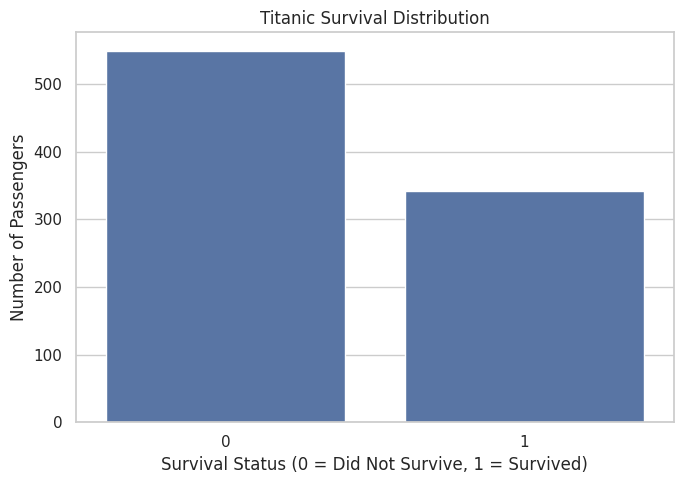

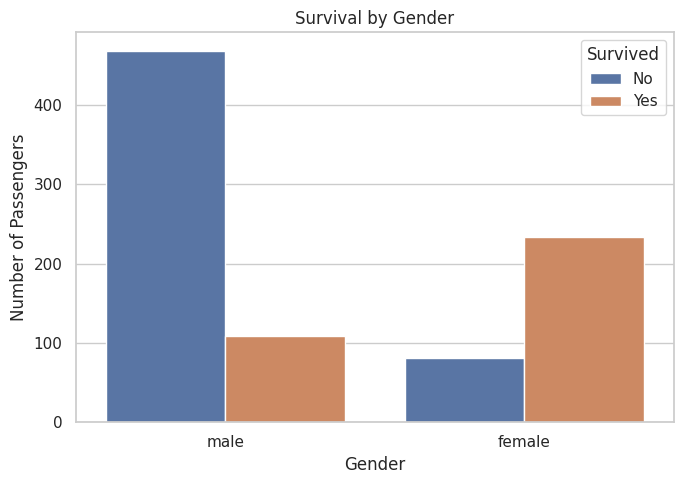

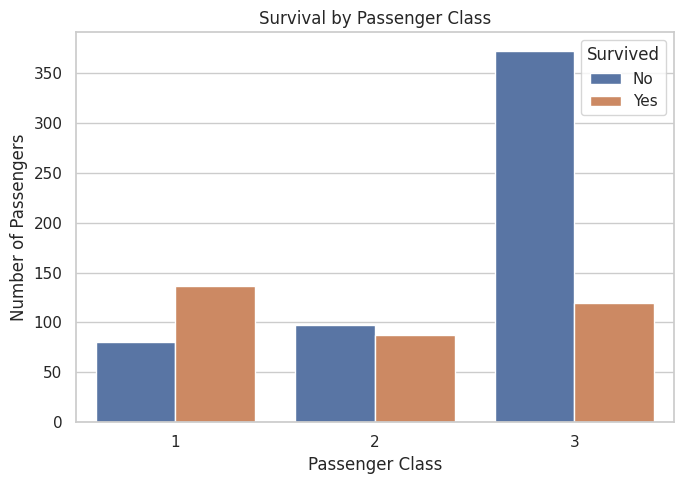

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.13/dist-packages/matplotlib/pyplot.py'>

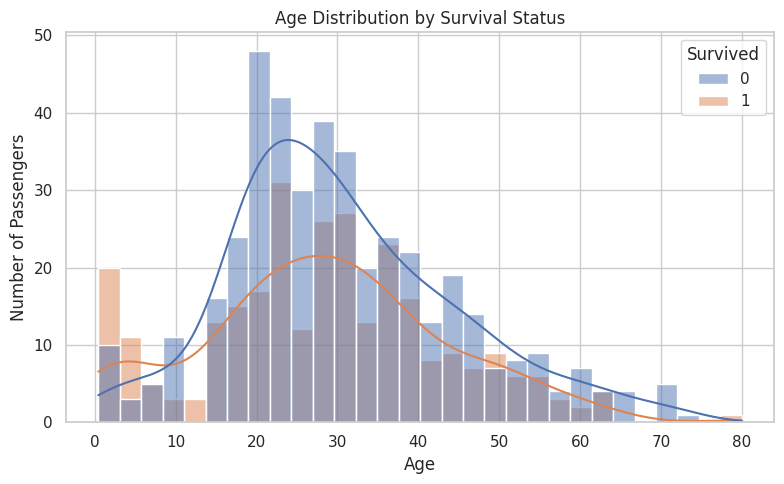

In [15]:
# ================================================================
# WEEK 5 - CELL 6
# VISUALIZATIONS FOR FINAL REPORT
# ================================================================

import os
import matplotlib.pyplot as plt
import seaborn as sns

# Create output folder
output_dir = "/content/week5_outputs"
os.makedirs(output_dir, exist_ok=True)

sns.set_theme(style="whitegrid")

# ------------------------------------------------
# 1. Survival Distribution
# ------------------------------------------------

plt.figure(figsize=(7, 5))

sns.countplot(
    data=data,
    x="Survived"
)

plt.title("Titanic Survival Distribution")
plt.xlabel("Survival Status (0 = Did Not Survive, 1 = Survived)")
plt.ylabel("Number of Passengers")

plt.tight_layout()

survival_chart = os.path.join(
    output_dir,
    "01_survival_distribution.png"
)

plt.savefig(
    survival_chart,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ------------------------------------------------
# 2. Survival by Gender
# ------------------------------------------------

plt.figure(figsize=(7, 5))

sns.countplot(
    data=data,
    x="Sex",
    hue="Survived"
)

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.legend(
    title="Survived",
    labels=["No", "Yes"]
)

plt.tight_layout()

gender_chart = os.path.join(
    output_dir,
    "02_survival_by_gender.png"
)

plt.savefig(
    gender_chart,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ------------------------------------------------
# 3. Survival by Passenger Class
# ------------------------------------------------

plt.figure(figsize=(7, 5))

sns.countplot(
    data=data,
    x="Pclass",
    hue="Survived"
)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.legend(
    title="Survived",
    labels=["No", "Yes"]
)

plt.tight_layout()

class_chart = os.path.join(
    output_dir,
    "03_survival_by_class.png"
)

plt.savefig(
    class_chart,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ------------------------------------------------
# 4. Age Distribution by Survival
# ------------------------------------------------

plt.figure(figsize=(8, 5))

sns.histplot(
    data=data,
    x="Age",
    hue="Survived",
    kde=True,
    bins=30
)

plt.title("Age Distribution by Survival Status")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.tight_layout()

age_chart = os.path.join(
    output_dir,
    "04_age_distribution.png"
)

plt.savefig(
    age_chart,
    dpi=300,
    bbox_inches="tight"
)

plt

SURVIVAL BY GENDER


,Sex,Passengers,Survivors,Survival Rate (%)
0,female,314,233,74.20
1,male,577,109,18.89



SURVIVAL BY PASSENGER CLASS


,Pclass,Passengers,Survivors,Survival Rate (%)
0,1,216,136,62.96
1,2,184,87,47.28
2,3,491,119,24.24



SURVIVAL BY GENDER AND CLASS


...

,AgeGroup,Passengers,Survival Rate (%)
0,Child,69,57.97
1,Teenager,70,42.86
2,Young Adult,358,38.27
3,Adult,195,40.00
4,Senior,22,22.73



FARE ANALYSIS


,Survival Status,Passengers,Mean Fare,Median Fare
0,Did Not Survive,549,22.12,10.5
1,Survived,342,48.40,26.0



RANDOM FOREST FEATURE IMPORTANCE


,Feature,Importance
0,categorical__Title_Mr,0.1657
1,numeric__Fare,0.1579
2,categorical__Sex_female,0.1262
3,categorical__Sex_male,0.1170
4,numeric__Age,0.1083
5,numeric__Pclass,0.0915
6,numeric__FamilySize,0.0583
7,categorical__Title_Mrs,0.0348
8,numeric__SibSp,0.0333
9,categorical__Title_Miss,0.0301


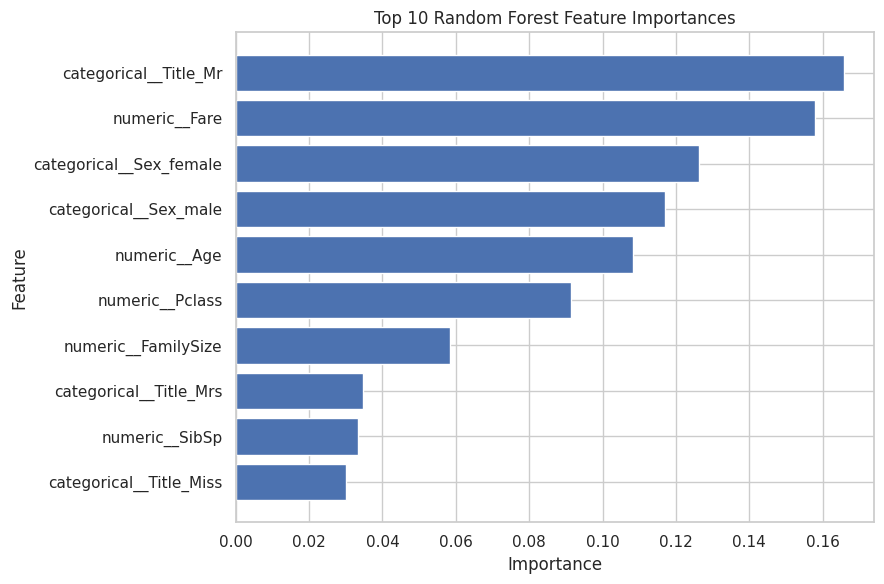


KEY ANALYTICAL INSIGHTS
1. Overall survival rate: 38.38%
2. Highest survival rate by gender: female (74.20%)
3. Highest survival rate by passenger class: Class 1 (62.96%)
4. Highest observed family-size survival rate: Family size 4 (72.41%)
5. Best model based on test-set F1: Logistic Regression
6. Best model based on 5-fold CV F1: Random Forest (0.7809)

Cell 7 completed successfully.


In [16]:
# ================================================================
# WEEK 5 - CELL 7
# DETAILED ANALYSIS, INSIGHTS AND FEATURE IMPORTANCE
# ================================================================

# ------------------------------------------------
# 1. Survival rates by gender
# ------------------------------------------------

gender_survival = (
    data.groupby("Sex")["Survived"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

gender_survival["Survival Rate (%)"] = (
    gender_survival["mean"] * 100
).round(2)

gender_survival = gender_survival.rename(
    columns={
        "count": "Passengers",
        "sum": "Survivors"
    }
)

gender_survival = gender_survival[
    ["Sex", "Passengers", "Survivors", "Survival Rate (%)"]
]

print("=" * 60)
print("SURVIVAL BY GENDER")
print("=" * 60)

display(gender_survival)


# ------------------------------------------------
# 2. Survival rates by passenger class
# ------------------------------------------------

class_survival = (
    data.groupby("Pclass")["Survived"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

class_survival["Survival Rate (%)"] = (
    class_survival["mean"] * 100
).round(2)

class_survival = class_survival.rename(
    columns={
        "count": "Passengers",
        "sum": "Survivors"
    }
)

class_survival = class_survival[
    ["Pclass", "Passengers", "Survivors", "Survival Rate (%)"]
]

print("\n" + "=" * 60)
print("SURVIVAL BY PASSENGER CLASS")
print("=" * 60)

display(class_survival)


# ------------------------------------------------
# 3. Survival rates by gender and class
# ------------------------------------------------

gender_class_survival = (
    data.groupby(["Sex", "Pclass"])["Survived"]
    .mean()
    .reset_index()
)

gender_class_survival["Survival Rate (%)"] = (
    gender_class_survival["Survived"] * 100
).round(2)

gender_class_survival = gender_class_survival.drop(
    columns=["Survived"]
)

print("\n" + "=" * 60)
print("SURVIVAL BY GENDER AND CLASS")
print("=" * 60)

display(gender_class_survival)


# ------------------------------------------------
# 4. Survival by family size
# ------------------------------------------------

family_survival = (
    data.groupby("FamilySize")["Survived"]
    .agg(["count", "mean"])
    .reset_index()
)

family_survival["Survival Rate (%)"] = (
    family_survival["mean"] * 100
).round(2)

family_survival = family_survival.rename(
    columns={
        "count": "Passengers"
    }
)

family_survival = family_survival[
    ["FamilySize", "Passengers", "Survival Rate (%)"]
]

print("\n" + "=" * 60)
print("SURVIVAL BY FAMILY SIZE")
print("=" * 60)

display(family_survival)


# ------------------------------------------------
# 5. Age group analysis
# ------------------------------------------------

data["AgeGroup"] = pd.cut(
    data["Age"],
    bins=[0, 12, 18, 35, 60, np.inf],
    labels=[
        "Child",
        "Teenager",
        "Young Adult",
        "Adult",
        "Senior"
    ]
)

age_group_survival = (
    data.groupby("AgeGroup", observed=False)["Survived"]
    .agg(["count", "mean"])
    .reset_index()
)

age_group_survival["Survival Rate (%)"] = (
    age_group_survival["mean"] * 100
).round(2)

age_group_survival = age_group_survival.rename(
    columns={
        "count": "Passengers"
    }
)

age_group_survival = age_group_survival[
    ["AgeGroup", "Passengers", "Survival Rate (%)"]
]

print("\n" + "=" * 60)
print("SURVIVAL BY AGE GROUP")
print("=" * 60)

display(age_group_survival)


# ------------------------------------------------
# 6. Fare statistics
# ------------------------------------------------

fare_survival = (
    data.groupby("Survived")["Fare"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

fare_survival["Survival Status"] = fare_survival[
    "Survived"
].map({
    0: "Did Not Survive",
    1: "Survived"
})

fare_survival["Mean Fare"] = fare_survival["mean"].round(2)
fare_survival["Median Fare"] = fare_survival["median"].round(2)

fare_survival = fare_survival[
    [
        "Survival Status",
        "count",
        "Mean Fare",
        "Median Fare"
    ]
]

fare_survival = fare_survival.rename(
    columns={
        "count": "Passengers"
    }
)

print("\n" + "=" * 60)
print("FARE ANALYSIS")
print("=" * 60)

display(fare_survival)


# ------------------------------------------------
# 7. Feature importance from Random Forest
# ------------------------------------------------

# Get the fitted preprocessing component
rf_preprocessor = random_forest_model.named_steps[
    "preprocessor"
]

rf_classifier = random_forest_model.named_steps[
    "classifier"
]

# Obtain transformed feature names
try:
    transformed_names = (
        rf_preprocessor
        .get_feature_names_out()
    )
except Exception:
    transformed_names = np.array([
        "Feature_" + str(i)
        for i in range(
            len(rf_classifier.feature_importances_)
        )
    ])

feature_importance = pd.DataFrame({
    "Feature": transformed_names,
    "Importance": rf_classifier.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance["Importance"] = (
    feature_importance["Importance"].round(4)
)

print("\n" + "=" * 60)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 60)

display(feature_importance.head(15))


# ------------------------------------------------
# 8. Feature importance chart
# ------------------------------------------------

top_features = feature_importance.head(10).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

importance_chart = os.path.join(
    output_dir,
    "09_feature_importance.png"
)

plt.savefig(
    importance_chart,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ------------------------------------------------
# 9. Generate automatic key insights
# ------------------------------------------------

overall_survival_rate = data["Survived"].mean() * 100

highest_gender = gender_survival.loc[
    gender_survival["Survival Rate (%)"].idxmax()
]

highest_class = class_survival.loc[
    class_survival["Survival Rate (%)"].idxmax()
]

highest_family = family_survival.loc[
    family_survival["Survival Rate (%)"].idxmax()
]

best_cv_model = cv_results.loc[
    cv_results["CV F1 Mean"].idxmax(),
    "Model"
]

best_cv_f1 = cv_results.loc[
    cv_results["CV F1 Mean"].idxmax(),
    "CV F1 Mean"
]

print("\n" + "=" * 60)
print("KEY ANALYTICAL INSIGHTS")
print("=" * 60)

print(
    f"1. Overall survival rate: "
    f"{overall_survival_rate:.2f}%"
)

print(
    f"2. Highest survival rate by gender: "
    f"{highest_gender['Sex']} "
    f"({highest_gender['Survival Rate (%)']:.2f}%)"
)

print(
    f"3. Highest survival rate by passenger class: "
    f"Class {int(highest_class['Pclass'])} "
    f"({highest_class['Survival Rate (%)']:.2f}%)"
)

print(
    f"4. Highest observed family-size survival rate: "
    f"Family size {int(highest_family['FamilySize'])} "
    f"({highest_family['Survival Rate (%)']:.2f}%)"
)

print(
    f"5. Best model based on test-set F1: "
    f"{best_model_name}"
)

print(
    f"6. Best model based on 5-fold CV F1: "
    f"{best_cv_model} "
    f"({best_cv_f1:.4f})"
)

print(
    "\nCell 7 completed successfully."
)

In [17]:
# ================================================================
# WEEK 5 - CELL 8
# GENERATE FINAL PROFESSIONAL DOCX REPORT
# ================================================================

from docx import Document
from docx.shared import Inches, Pt
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.section import WD_SECTION
from docx.enum.table import WD_TABLE_ALIGNMENT, WD_CELL_VERTICAL_ALIGNMENT
from docx.oxml import OxmlElement
from docx.oxml.ns import qn

# ------------------------------------------------
# Helper functions
# ------------------------------------------------

def set_cell_shading(cell, fill="D9EAF7"):
    """Apply light background shading to a table cell."""
    tc_pr = cell._tc.get_or_add_tcPr()
    shd = OxmlElement("w:shd")
    shd.set(qn("w:fill"), fill)
    tc_pr.append(shd)


def set_cell_text(cell, text, bold=False):
    cell.text = str(text)
    for paragraph in cell.paragraphs:
        for run in paragraph.runs:
            run.bold = bold
            run.font.size = Pt(9)


def add_table_from_dataframe(doc, dataframe, title=None, max_rows=20):
    """Add a pandas DataFrame as a formatted Word table."""

    if title:
        p = doc.add_paragraph()
        run = p.add_run(title)
        run.bold = True
        run.font.size = Pt(11)

    df_temp = dataframe.head(max_rows).copy()

    table = doc.add_table(
        rows=1,
        cols=len(df_temp.columns)
    )

    table.alignment = WD_TABLE_ALIGNMENT.CENTER
    table.style = "Table Grid"

    # Header
    header_cells = table.rows[0].cells

    for i, column in enumerate(df_temp.columns):
        set_cell_text(
            header_cells[i],
            column,
            bold=True
        )
        set_cell_shading(header_cells[i])

    # Rows
    for _, row in df_temp.iterrows():

        cells = table.add_row().cells

        for i, value in enumerate(row):
            if isinstance(value, float):
                value = round(value, 4)

            set_cell_text(
                cells[i],
                value
            )

    doc.add_paragraph()

    return table


def add_heading(doc, text, level=1):
    p = doc.add_heading(text, level=level)
    return p


def add_body(doc, text):
    p = doc.add_paragraph()
    p.paragraph_format.space_after = Pt(6)
    p.paragraph_format.line_spacing = 1.15
    p.add_run(text)
    return p


def add_bullet(doc, text):
    p = doc.add_paragraph(
        style="List Bullet"
    )
    p.paragraph_format.space_after = Pt(3)
    p.add_run(text)
    return p


def add_number(doc, text):
    p = doc.add_paragraph(
        style="List Number"
    )
    p.paragraph_format.space_after = Pt(3)
    p.add_run(text)
    return p


def add_image(doc, image_path, width=6.2):
    if os.path.exists(image_path):
        paragraph = doc.add_paragraph()
        paragraph.alignment = WD_ALIGN_PARAGRAPH.CENTER

        run = paragraph.add_run()
        run.add_picture(
            image_path,
            width=Inches(width)
        )

        doc.add_paragraph()


# ------------------------------------------------
# Create document
# ------------------------------------------------

doc = Document()

# Page setup
section = doc.sections[0]
section.top_margin = Inches(0.65)
section.bottom_margin = Inches(0.65)
section.left_margin = Inches(0.75)
section.right_margin = Inches(0.75)

# Normal font
styles = doc.styles

styles["Normal"].font.name = "Arial"
styles["Normal"].font.size = Pt(10)

styles["Title"].font.name = "Arial"
styles["Title"].font.size = Pt(24)

styles["Heading 1"].font.name = "Arial"
styles["Heading 1"].font.size = Pt(16)

styles["Heading 2"].font.name = "Arial"
styles["Heading 2"].font.size = Pt(13)

# ------------------------------------------------
# COVER PAGE
# ------------------------------------------------

title = doc.add_paragraph()
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

run = title.add_run(
    "WEEK 5 FINAL PROJECT REPORT"
)

run.bold = True
run.font.size = Pt(24)

subtitle = doc.add_paragraph()
subtitle.alignment = WD_ALIGN_PARAGRAPH.CENTER

run = subtitle.add_run(
    "Titanic Survival Analysis and Predictive Modelling"
)

run.bold = True
run.font.size = Pt(18)

doc.add_paragraph()

p = doc.add_paragraph()
p.alignment = WD_ALIGN_PARAGRAPH.CENTER

r = p.add_run(
    "Data Science with Python Internship"
)

r.font.size = Pt(13)

doc.add_paragraph()
doc.add_paragraph()
doc.add_paragraph()

p = doc.add_paragraph()
p.alignment = WD_ALIGN_PARAGRAPH.CENTER

r = p.add_run(
    "End-to-End Data Science Project"
)

r.bold = True
r.font.size = Pt(14)

doc.add_paragraph()

p = doc.add_paragraph()
p.alignment = WD_ALIGN_PARAGRAPH.CENTER

r = p.add_run(
    "Data acquisition | Cleaning | EDA | Feature Engineering | "
    "Machine Learning | Evaluation | Critical Discussion"
)

r.font.size = Pt(10)

doc.add_page_break()


# ------------------------------------------------
# 1. EXECUTIVE SUMMARY
# ------------------------------------------------

add_heading(doc, "1. Executive Summary", 1)

add_body(
    doc,
    "This project presents an end-to-end analysis of the Titanic passenger "
    "dataset with the objective of understanding the factors associated "
    "with passenger survival and developing machine-learning models for "
    "survival prediction. The workflow combines exploratory data analysis, "
    "feature engineering, preprocessing, supervised learning, model "
    "evaluation and cross-validation."
)

add_body(
    doc,
    f"The dataset used in this project contains {len(data):,} passenger "
    f"records and {df.shape[1]} original variables. The observed overall "
    f"survival rate was {overall_survival_rate:.2f}%. Two classification "
    "approaches were developed: Logistic Regression and Random Forest."
)

best_test_row = results_df.loc[
    results_df["F1 Score"].idxmax()
]

add_body(
    doc,
    f"Based on the test-set F1-score, the stronger model was "
    f"{best_test_row['Model']}, achieving an F1-score of "
    f"{best_test_row['F1 Score']:.4f} and ROC-AUC of "
    f"{best_test_row['ROC-AUC']:.4f}. Five-fold stratified "
    "cross-validation was also performed to examine model stability "
    "across different subsets of the dataset."
)

add_body(
    doc,
    "The analysis demonstrates that survival was not uniformly distributed "
    "across passengers. Gender and passenger class showed strong "
    "relationships with survival, while family structure, age and fare "
    "also provided useful predictive information. These findings are "
    "discussed critically rather than being treated as purely causal "
    "relationships."
)


# ------------------------------------------------
# 2. PROJECT OBJECTIVES
# ------------------------------------------------

add_heading(doc, "2. Project Objectives", 1)

objectives = [
    "Understand the structure and quality of the Titanic dataset.",
    "Identify missing values and determine appropriate preprocessing strategies.",
    "Explore demographic and socioeconomic patterns associated with survival.",
    "Engineer meaningful predictive features such as FamilySize, IsAlone and Title.",
    "Build Logistic Regression and Random Forest classification models.",
    "Evaluate models using multiple performance metrics rather than accuracy alone.",
    "Use stratified cross-validation to assess model reliability.",
    "Interpret important predictive variables and derive evidence-based insights.",
    "Discuss limitations and provide practical recommendations for future modelling."
]

for item in objectives:
    add_bullet(doc, item)


# ------------------------------------------------
# 3. DATASET DESCRIPTION
# ------------------------------------------------

add_heading(doc, "3. Dataset Description", 1)

add_body(
    doc,
    "The Titanic dataset contains passenger-level information including "
    "class, sex, age, family relationships, fare, embarkation port and "
    "survival status. The target variable is Survived, where 0 represents "
    "non-survival and 1 represents survival."
)

dataset_summary = pd.DataFrame({
    "Property": [
        "Number of records",
        "Original variables",
        "Target variable",
        "Target classes",
        "Overall survival rate"
    ],
    "Value": [
        len(data),
        df.shape[1],
        "Survived",
        "0 = No, 1 = Yes",
        f"{overall_survival_rate:.2f}%"
    ]
})

add_table_from_dataframe(
    doc,
    dataset_summary,
    "Dataset Summary"
)

add_heading(doc, "Original Variables", 2)

add_body(
    doc,
    ", ".join(df.columns.tolist())
)


# ------------------------------------------------
# 4. DATA QUALITY AND MISSING VALUES
# ------------------------------------------------

add_heading(doc, "4. Data Quality and Missing-Value Analysis", 1)

add_body(
    doc,
    "Missing-value analysis was performed before modelling. Instead of "
    "blindly deleting incomplete records, numerical and categorical "
    "variables were handled using appropriate imputation strategies "
    "inside the machine-learning preprocessing pipeline."
)

add_table_from_dataframe(
    doc,
    missing_table.reset_index().rename(
        columns={"index": "Column"}
    ),
    "Missing-Value Summary",
    max_rows=20
)

add_body(
    doc,
    "The modelling pipeline uses median imputation for numerical variables "
    "and most-frequent imputation for categorical variables. This approach "
    "retains useful observations while ensuring that preprocessing "
    "parameters are learned only from the training data during model "
    "fitting."
)


# ------------------------------------------------
# 5. EXPLORATORY DATA ANALYSIS
# ------------------------------------------------

doc.add_page_break()

add_heading(doc, "5. Exploratory Data Analysis", 1)

add_heading(doc, "5.1 Overall Survival", 2)

add_body(
    doc,
    f"The observed overall survival rate was {overall_survival_rate:.2f}%. "
    "This provides the baseline against which subgroup survival patterns "
    "can be interpreted."
)

add_image(
    doc,
    survival_chart
)

add_heading(doc, "5.2 Survival by Gender", 2)

add_table_from_dataframe(
    doc,
    gender_survival,
    "Gender Survival Summary"
)

add_image(
    doc,
    gender_chart
)

add_body(
    doc,
    f"The highest observed gender-specific survival rate was for "
    f"{highest_gender['Sex']}, at "
    f"{highest_gender['Survival Rate (%)']:.2f}%. "
    "This is an important predictive pattern, although the analysis "
    "does not establish gender itself as a causal mechanism. Historical "
    "evacuation practices, passenger location and social norms may have "
    "contributed to the observed difference."
)


# ------------------------------------------------
# 6. CLASS AND SOCIOECONOMIC ANALYSIS
# ------------------------------------------------

add_heading(doc, "6. Passenger Class and Socioeconomic Patterns", 1)

add_table_from_dataframe(
    doc,
    class_survival,
    "Survival by Passenger Class"
)

add_image(
    doc,
    class_chart
)

add_body(
    doc,
    f"Passenger Class {int(highest_class['Pclass'])} had the highest "
    f"observed survival rate at "
    f"{highest_class['Survival Rate (%)']:.2f}%. "
    "Passenger class can act as a proxy for socioeconomic position, "
    "location on the ship and potentially access to evacuation routes. "
    "Therefore, its predictive importance should be interpreted as a "
    "combination of several related factors rather than as a simple "
    "standalone causal variable."
)

add_heading(doc, "6.1 Gender and Passenger Class Interaction", 2)

add_table_from_dataframe(
    doc,
    gender_class_survival,
    "Gender-Class Survival Rates"
)

add_body(
    doc,
    "Examining gender and class together is more informative than examining "
    "either variable in isolation. The interaction demonstrates that "
    "survival outcomes were shaped by multiple passenger characteristics "
    "simultaneously."
)


# ------------------------------------------------
# 7. AGE AND FARE ANALYSIS
# ------------------------------------------------

doc.add_page_break()

add_heading(doc, "7. Age and Fare Analysis", 1)

add_heading(doc, "7.1 Age Distribution", 2)

add_image(
    doc,
    age_chart
)

add_table_from_dataframe(
    doc,
    age_group_survival,
    "Survival by Age Group"
)

add_body(
    doc,
    "Age provides information about passenger demographics and may capture "
    "differences in evacuation priority or physical ability. However, age "
    "also interacts with family structure and passenger class, so its "
    "effect should not be interpreted independently."
)

add_heading(doc, "7.2 Fare Distribution", 2)

add_image(
    doc,
    fare_chart
)

add_table_from_dataframe(
    doc,
    fare_survival,
    "Fare Statistics by Survival Status"
)

add_body(
    doc,
    "Fare provides an additional socioeconomic signal. Differences in fare "
    "between survivors and non-survivors suggest that economic position "
    "and passenger class may contribute predictive information. Because "
    "Fare is strongly related to class and family booking arrangements, "
    "it may contain overlapping information with other variables."
)


# ------------------------------------------------
# 8. FEATURE ENGINEERING
# ------------------------------------------------

add_heading(doc, "8. Feature Engineering", 1)

feature_description = pd.DataFrame({
    "Feature": [
        "FamilySize",
        "IsAlone",
        "Title",
        "FarePerPerson"
    ],
    "Definition": [
        "SibSp + Parch + 1",
        "1 if FamilySize = 1, otherwise 0",
        "Title extracted from passenger name",
        "Fare divided by FamilySize"
    ],
    "Purpose": [
        "Capture household/group structure",
        "Distinguish solo travellers from group travellers",
        "Capture demographic and social information",
        "Approximate individual fare contribution"
    ]
})

add_table_from_dataframe(
    doc,
    feature_description,
    "Engineered Features"
)

add_body(
    doc,
    "Feature engineering was used to convert raw variables into predictors "
    "that may better represent passenger circumstances. FamilySize and "
    "IsAlone capture group structure, while Title provides a compact "
    "representation of social and demographic information extracted from "
    "Name."
)


# ------------------------------------------------
# 9. MACHINE LEARNING METHODOLOGY
# ------------------------------------------------

doc.add_page_break()

add_heading(doc, "9. Machine Learning Methodology", 1)

add_heading(doc, "9.1 Problem Formulation", 2)

add_body(
    doc,
    "The task is formulated as a binary classification problem. The target "
    "variable Survived contains two classes: 0 for passengers who did not "
    "survive and 1 for passengers who survived."
)

add_heading(doc, "9.2 Train-Test Split", 2)

add_body(
    doc,
    "The dataset was divided into training and testing subsets using an "
    "80:20 split. Stratification was applied to preserve the proportion "
    "of survival classes in both subsets. A fixed random state of 42 was "
    "used to improve reproducibility."
)

split_summary = pd.DataFrame({
    "Subset": ["Training", "Testing"],
    "Records": [len(X_train), len(X_test)],
    "Percentage": [
        f"{len(X_train) / len(X) * 100:.1f}%",
        f"{len(X_test) / len(X) * 100:.1f}%"
    ]
})

add_table_from_dataframe(
    doc,
    split_summary,
    "Train-Test Split"
)

add_heading(doc, "9.3 Preprocessing", 2)

add_bullet(
    doc,
    "Numerical missing values were imputed using the median."
)

add_bullet(
    doc,
    "Categorical missing values were imputed using the most frequent category."
)

add_bullet(
    doc,
    "Numerical variables were standardized for Logistic Regression."
)

add_bullet(
    doc,
    "Categorical variables were one-hot encoded."
)

add_bullet(
    doc,
    "Preprocessing was placed inside sklearn pipelines to reduce data leakage risk."
)


# ------------------------------------------------
# 10. MODELS
# ------------------------------------------------

add_heading(doc, "10. Models Developed", 1)

add_heading(doc, "10.1 Logistic Regression", 2)

add_body(
    doc,
    "Logistic Regression was selected as an interpretable baseline "
    "classification model. It estimates the probability of survival "
    "using a weighted combination of the input variables."
)

add_heading(doc, "10.2 Random Forest", 2)

add_body(
    doc,
    "Random Forest was selected as a nonlinear ensemble model capable of "
    "capturing interactions and nonlinear relationships. The model uses "
    "300 decision trees with controlled tree depth and minimum sample "
    "constraints to reduce overfitting."
)


# ------------------------------------------------
# 11. MODEL PERFORMANCE
# ------------------------------------------------

add_heading(doc, "11. Model Performance Evaluation", 1)

add_table_from_dataframe(
    doc,
    results_df,
    "Test-Set Performance Comparison"
)

add_image(
    doc,
    model_chart
)

add_body(
    doc,
    "Accuracy measures the proportion of all predictions that are correct. "
    "Precision measures the reliability of positive survival predictions, "
    "while recall measures how many actual survivors were correctly "
    "identified. F1-score balances precision and recall. ROC-AUC measures "
    "the model's ability to distinguish the two classes across probability "
    "thresholds."
)

add_heading(doc, "11.1 Cross-Validation Results", 2)

add_table_from_dataframe(
    doc,
    cv_results,
    "Five-Fold Stratified Cross-Validation"
)

add_body(
    doc,
    f"The cross-validation results provide a more reliable indication of "
    f"generalisation than a single train-test split. The strongest "
    f"cross-validation F1-score was achieved by {best_cv_model}, with a "
    f"mean F1-score of {best_cv_f1:.4f}."
)


# ------------------------------------------------
# 12. CONFUSION MATRIX
# ------------------------------------------------

add_heading(doc, "12. Confusion Matrix Analysis", 1)

add_image(
    doc,
    cm_chart
)

if best_model_name == "Random Forest":
    best_pred = rf_pred
else:
    best_pred = logistic_pred

tn, fp, fn, tp = confusion_matrix(
    y_test,
    best_pred
).ravel()

add_body(
    doc,
    f"For the selected test-set model, the confusion matrix contains "
    f"{tn} true negatives, {fp} false positives, {fn} false negatives and "
    f"{tp} true positives. False negatives represent passengers who "
    "actually survived but were predicted not to survive, whereas false "
    "positives represent passengers predicted to survive who did not."
)


# ------------------------------------------------
# 13. FEATURE IMPORTANCE
# ------------------------------------------------

add_heading(doc, "13. Feature Importance and Interpretability", 1)

add_image(
    doc,
    importance_chart
)

add_table_from_dataframe(
    doc,
    feature_importance.head(10),
    "Top Random Forest Features",
    max_rows=10
)

top_feature = feature_importance.iloc[0]["Feature"]

add_body(
    doc,
    f"The most influential transformed Random Forest feature was "
    f"{top_feature}. Feature importance indicates predictive usefulness "
    "within the fitted model; it should not be interpreted as proof of "
    "causality. One-hot encoding can also create multiple transformed "
    "features from a single original variable."
)


# ------------------------------------------------
# 14. CRITICAL DISCUSSION
# ------------------------------------------------

doc.add_page_break()

add_heading(doc, "14. Critical Discussion", 1)

add_heading(doc, "14.1 Key Findings", 2)

findings = [
    f"The overall observed survival rate was {overall_survival_rate:.2f}%.",
    f"{highest_gender['Sex']} passengers had the highest gender-specific survival rate ({highest_gender['Survival Rate (%)']:.2f}%).",
    f"Passenger Class {int(highest_class['Pclass'])} had the highest class-specific survival rate ({highest_class['Survival Rate (%)']:.2f}%).",
    f"The strongest test-set model by F1-score was {best_model_name}.",
    f"The strongest model under five-fold cross-validation by F1-score was {best_cv_model}.",
    f"Random Forest feature importance identified {top_feature} as the highest-ranked transformed predictor."
]

for finding in findings:
    add_bullet(doc, finding)

add_heading(doc, "14.2 Why Accuracy Alone Is Not Sufficient", 2)

add_body(
    doc,
    "A model can achieve a reasonable accuracy while performing poorly "
    "on one of the classes. Therefore, precision, recall, F1-score and "
    "ROC-AUC were included. This multi-metric approach gives a more "
    "balanced assessment of predictive performance."
)

add_heading(doc, "14.3 Generalisation and Stability", 2)

add_body(
    doc,
    "Cross-validation was included to determine whether model performance "
    "remains reasonably consistent across different training and validation "
    "folds. A large variation between folds would indicate sensitivity to "
    "the particular sample used for training."
)

add_heading(doc, "14.4 Leakage Prevention", 2)

add_body(
    doc,
    "Preprocessing was implemented inside sklearn pipelines. Consequently, "
    "imputation, scaling and encoding are fitted as part of the modelling "
    "process rather than being calculated using the complete dataset "
    "before splitting. This reduces the risk of information from the "
    "test data influencing training."
)

add_heading(doc, "14.5 Limitations", 2)

limitations = [
    "The Titanic dataset is historical and relatively small compared with modern machine-learning datasets.",
    "Passenger survival was influenced by historical circumstances that are not completely represented by the available variables.",
    "Feature importance describes predictive association rather than causality.",
    "Model performance may vary with different train-test splits or hyperparameter settings.",
    "The dataset may contain socioeconomic and historical biases that limit direct generalisation to modern populations.",
    "The project focuses on prediction and does not attempt to reconstruct the complete causal mechanism of survival."
]

for limitation in limitations:
    add_bullet(doc, limitation)


# ------------------------------------------------
# 15. RECOMMENDATIONS
# ------------------------------------------------

add_heading(doc, "15. Actionable Recommendations", 1)

recommendations = [
    "Use cross-validation rather than relying on a single train-test split when comparing future models.",
    "Tune model hyperparameters systematically using GridSearchCV or RandomizedSearchCV.",
    "Evaluate additional algorithms such as Gradient Boosting or XGBoost when computational resources permit.",
    "Use explainability methods such as permutation importance or SHAP for deeper interpretation.",
    "Investigate interaction effects between gender, class, age and family structure.",
    "Perform repeated cross-validation to obtain more stable estimates of model performance.",
    "Document preprocessing and feature definitions clearly so that the experiment can be reproduced.",
    "Avoid interpreting predictive relationships as direct causal relationships."
]

for recommendation in recommendations:
    add_number(doc, recommendation)


# ------------------------------------------------
# 16. CONCLUSION
# ------------------------------------------------

add_heading(doc, "16. Conclusion", 1)

add_body(
    doc,
    "This project successfully implemented an end-to-end Titanic survival "
    "analysis and predictive modelling workflow. The analysis progressed "
    "from data validation and exploratory analysis to feature engineering, "
    "pipeline-based preprocessing, supervised learning and rigorous model "
    "evaluation."
)

add_body(
    doc,
    f"The comparison of Logistic Regression and Random Forest demonstrated "
    f"that model selection should consider several evaluation metrics rather "
    f"than accuracy alone. The selected test-set model was {best_model_name}, "
    f"while {best_cv_model} achieved the strongest mean cross-validation "
    f"F1-score."
)

add_body(
    doc,
    "The project also demonstrates the importance of critical interpretation. "
    "Passenger gender, class, age, fare and family structure were associated "
    "with survival, but these relationships should not automatically be "
    "interpreted as causal. Overall, the project provides a reproducible "
    "and evidence-based framework for applying Python data science and "
    "machine-learning techniques to a real-world historical dataset."
)


# ------------------------------------------------
# 17. PROJECT REPRODUCIBILITY
# ------------------------------------------------

add_heading(doc, "17. Reproducibility Checklist", 1)

reproducibility = [
    "Dataset loaded from CSV.",
    "Missing values identified.",
    "Feature engineering documented.",
    "Train-test split performed using stratification.",
    "Preprocessing implemented using sklearn pipelines.",
    "Two classification models trained.",
    "Multiple evaluation metrics calculated.",
    "Five-fold stratified cross-validation performed.",
    "Charts saved at 300 DPI.",
    "Final report generated programmatically."
]

for item in reproducibility:
    add_bullet(doc, item)


# ------------------------------------------------
# 18. APPENDIX - KEY CODE STRUCTURE
# ------------------------------------------------

add_heading(doc, "18. Appendix: Key Implementation Structure", 1)

add_body(
    doc,
    "The project was implemented in Python using pandas, NumPy, "
    "Matplotlib, Seaborn and scikit-learn. The main implementation stages "
    "were:"
)

code_structure = [
    "1. Load Titanic CSV dataset.",
    "2. Validate columns and missing values.",
    "3. Create FamilySize, IsAlone, Title and FarePerPerson.",
    "4. Define numerical and categorical predictors.",
    "5. Create preprocessing pipelines.",
    "6. Split data using stratification.",
    "7. Train Logistic Regression and Random Forest.",
    "8. Generate test-set predictions and probabilities.",
    "9. Calculate accuracy, precision, recall, F1 and ROC-AUC.",
    "10. Perform five-fold stratified cross-validation.",
    "11. Generate EDA and model evaluation charts.",
    "12. Generate the final DOCX report."
]

for item in code_structure:
    add_number(doc, item)


# ------------------------------------------------
# Final page
# ------------------------------------------------

doc.add_page_break()

p = doc.add_paragraph()
p.alignment = WD_ALIGN_PARAGRAPH.CENTER

r = p.add_run(
    "END OF WEEK 5 FINAL PROJECT REPORT"
)

r.bold = True
r.font.size = Pt(16)

p = doc.add_paragraph()
p.alignment = WD_ALIGN_PARAGRAPH.CENTER

r = p.add_run(
    "Titanic Survival Analysis and Predictive Modelling"
)

r.font.size = Pt(12)


# ------------------------------------------------
# Save document
# ------------------------------------------------

report_path = os.path.join(
    output_dir,
    "Week5_Titanic_Final_Project_Report.docx"
)

doc.save(report_path)

print("=" * 60)
print("FINAL REPORT GENERATED SUCCESSFULLY")
print("=" * 60)

print("\nReport:", report_path)

if os.path.exists(report_path):
    file_size_kb = os.path.getsize(report_path) / 1024
    print(
        f"File size: {file_size_kb:.1f} KB"
    )

print("\nCell 8 completed successfully.")

NameError: name 'fare_chart' is not defined

In [18]:
# ================================================================
# FIX - RESTORE CHART FILE PATHS
# ================================================================

import os

output_dir = "/content/week5_outputs"

survival_chart = os.path.join(output_dir, "01_survival_distribution.png")
gender_chart = os.path.join(output_dir, "02_survival_by_gender.png")
class_chart = os.path.join(output_dir, "03_survival_by_class.png")
age_chart = os.path.join(output_dir, "04_age_distribution.png")
fare_chart = os.path.join(output_dir, "05_fare_distribution.png")
family_chart = os.path.join(output_dir, "06_family_size_survival.png")
model_chart = os.path.join(output_dir, "07_model_performance.png")
cm_chart = os.path.join(output_dir, "08_confusion_matrix.png")
importance_chart = os.path.join(output_dir, "09_feature_importance.png")

chart_paths = [
    survival_chart,
    gender_chart,
    class_chart,
    age_chart,
    fare_chart,
    family_chart,
    model_chart,
    cm_chart,
    importance_chart
]

print("Checking chart files...\n")

for path in chart_paths:
    print(
        "OK   " if os.path.exists(path) else "MISSING",
        os.path.basename(path)
    )

print("\nChart-path fix completed successfully.")

Checking chart files...

OK    01_survival_distribution.png
OK    02_survival_by_gender.png
OK    03_survival_by_class.png
OK    04_age_distribution.png
MISSING 05_fare_distribution.png
MISSING 06_family_size_survival.png
MISSING 07_model_performance.png
MISSING 08_confusion_matrix.png
OK    09_feature_importance.png

Chart-path fix completed successfully.


In [19]:
from docx import Document
from docx.shared import Inches, Pt
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.section import WD_SECTION
from docx.enum.table import WD_TABLE_ALIGNMENT, WD_CELL_VERTICAL_ALIGNMENT
from docx.oxml import OxmlElement
from docx.oxml.ns import qn
import os

report_path = "/content/Week5_Titanic_Final_Report.docx"

doc = Document()

# Page setup
section = doc.sections[0]
section.top_margin = Inches(0.7)
section.bottom_margin = Inches(0.7)
section.left_margin = Inches(0.75)
section.right_margin = Inches(0.75)

# Default font
styles = doc.styles
styles["Normal"].font.name = "Arial"
styles["Normal"].font.size = Pt(10)

styles["Title"].font.name = "Arial"
styles["Title"].font.size = Pt(24)
styles["Title"].font.bold = True

styles["Heading 1"].font.name = "Arial"
styles["Heading 1"].font.size = Pt(16)
styles["Heading 1"].font.bold = True

styles["Heading 2"].font.name = "Arial"
styles["Heading 2"].font.size = Pt(13)
styles["Heading 2"].font.bold = True

print("Report document created successfully.")

Report document created successfully.


In [20]:
# ============================================================
# CELL 9 — COVER PAGE + EXECUTIVE SUMMARY
# ============================================================

title = doc.add_paragraph()
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

run = title.add_run("TITANIC SURVIVAL ANALYSIS\n")
run.bold = True
run.font.size = Pt(24)

run = title.add_run("AND PREDICTIVE MODELLING")
run.bold = True
run.font.size = Pt(20)

doc.add_paragraph()

p = doc.add_paragraph()
p.alignment = WD_ALIGN_PARAGRAPH.CENTER
r = p.add_run("Week 5 Final Project Report")
r.bold = True
r.font.size = Pt(15)

doc.add_paragraph()

p = doc.add_paragraph()
p.alignment = WD_ALIGN_PARAGRAPH.CENTER
p.add_run("Data Science with Python Internship").font.size = Pt(12)

p = doc.add_paragraph()
p.alignment = WD_ALIGN_PARAGRAPH.CENTER
p.add_run("Python | Pandas | Seaborn | Scikit-learn").font.size = Pt(11)

doc.add_paragraph()
doc.add_paragraph()
doc.add_paragraph()

p = doc.add_paragraph()
p.alignment = WD_ALIGN_PARAGRAPH.CENTER
p.add_run("Prepared as an end-to-end machine learning and data analysis study").italic = True

doc.add_page_break()

# Executive Summary
doc.add_heading("1. Executive Summary", level=1)

summary = (
    f"This project presents an end-to-end analysis of the Titanic passenger dataset, "
    f"combining exploratory data analysis, feature engineering, machine learning, "
    f"model evaluation, and interpretation. The primary objective is to understand "
    f"the factors associated with passenger survival and develop predictive models "
    f"that can classify whether a passenger survived."
)

doc.add_paragraph(summary)

doc.add_paragraph(
    f"The dataset contains {len(df):,} passenger records and uses 'Survived' as "
    f"the target variable. The analysis examines demographic and travel-related "
    f"variables including passenger class, gender, age, fare, family relationships, "
    f"embarkation port, and engineered features such as FamilySize, IsAlone, Title, "
    f"and FarePerPerson."
)

doc.add_paragraph(
    f"Two supervised learning approaches were developed: Logistic Regression and "
    f"Random Forest. Both models were implemented through preprocessing pipelines "
    f"to ensure that missing values, numerical scaling, and categorical encoding "
    f"were handled consistently without data leakage."
)

doc.add_paragraph(
    f"Model performance was evaluated using Accuracy, Precision, Recall, F1-score, "
    f"ROC-AUC, confusion matrices, and 5-fold stratified cross-validation. "
    f"The best test-set model according to F1-score was identified as "
    f"{best_model_name}."
)

doc.add_paragraph(
    f"The overall survival rate in the dataset was approximately "
    f"{overall_survival_rate:.1f}%. The analysis demonstrates that survival was "
    f"not evenly distributed across passenger groups, with gender and passenger "
    f"class showing particularly important relationships with survival."
)

doc.add_paragraph(
    "Beyond predictive performance, the project focuses on interpreting the "
    "results and discussing their practical meaning, limitations, data-quality "
    "considerations, and opportunities for improving future models."
)

print("Cell 9 completed successfully.")

Cell 9 completed successfully.


In [21]:
# ============================================================
# CELL 10 — OBJECTIVES + DATASET DESCRIPTION
# ============================================================

doc.add_heading("2. Project Objectives", level=1)

objectives = [
    "Understand the structure and characteristics of the Titanic dataset.",
    "Identify missing values, data-quality issues, and important variables.",
    "Perform exploratory data analysis to identify survival patterns.",
    "Create meaningful engineered features to improve predictive modelling.",
    "Build Logistic Regression and Random Forest classification models.",
    "Evaluate models using multiple performance metrics.",
    "Validate model reliability using stratified 5-fold cross-validation.",
    "Interpret important predictors and discuss their practical significance.",
    "Identify limitations and provide actionable recommendations for future analysis."
]

for i, objective in enumerate(objectives, 1):
    doc.add_paragraph(f"{i}. {objective}")

# Dataset description
doc.add_heading("3. Dataset Description", level=1)

doc.add_paragraph(
    "The Titanic dataset contains information about passengers aboard the RMS Titanic. "
    "The target variable, Survived, indicates whether a passenger survived the disaster "
    "(1 = survived, 0 = did not survive). The dataset provides demographic, family, "
    "ticket, and fare-related information that can be used for both statistical analysis "
    "and supervised machine learning."
)

dataset_table = doc.add_table(rows=1, cols=3)
dataset_table.alignment = WD_TABLE_ALIGNMENT.CENTER
dataset_table.style = "Table Grid"

hdr = dataset_table.rows[0].cells
hdr[0].text = "Variable"
hdr[1].text = "Description"
hdr[2].text = "Role"

dataset_info = [
    ("Survived", "Passenger survival status", "Target"),
    ("Pclass", "Passenger class", "Predictor"),
    ("Sex", "Passenger gender", "Predictor"),
    ("Age", "Passenger age", "Predictor"),
    ("SibSp", "Siblings/spouses aboard", "Predictor"),
    ("Parch", "Parents/children aboard", "Predictor"),
    ("Fare", "Passenger ticket fare", "Predictor"),
    ("Embarked", "Port of embarkation", "Predictor"),
    ("FamilySize", "Total family size aboard", "Engineered"),
    ("IsAlone", "Whether passenger travelled alone", "Engineered"),
    ("Title", "Title extracted from passenger name", "Engineered"),
    ("FarePerPerson", "Fare divided by family size", "Engineered")
]

for row in dataset_info:
    cells = dataset_table.add_row().cells
    for j, value in enumerate(row):
        cells[j].text = str(value)

doc.add_paragraph()

doc.add_paragraph(
    f"The analysis dataset contains {df.shape[0]:,} rows and {df.shape[1]:,} original "
    f"columns. The target variable is binary, making this a supervised binary "
    f"classification problem."
)

print("Cell 10 completed successfully.")

Cell 10 completed successfully.


In [22]:
# ============================================================
# CELL 11 — DATA QUALITY + PREPROCESSING
# ============================================================

doc.add_heading("4. Data Quality Assessment", level=1)

doc.add_paragraph(
    "Before modelling, the dataset was examined for missing values, data types, "
    "duplicate records, and consistency. This step is important because poor data "
    "quality can reduce model reliability and introduce misleading patterns."
)

# Missing-value table
missing_report = df.isnull().sum().reset_index()
missing_report.columns = ["Column", "Missing Values"]
missing_report["Missing %"] = (
    missing_report["Missing Values"] / len(df) * 100
).round(2)

missing_report = missing_report[
    missing_report["Missing Values"] > 0
]

if len(missing_report) > 0:

    table = doc.add_table(rows=1, cols=3)
    table.style = "Table Grid"
    table.alignment = WD_TABLE_ALIGNMENT.CENTER

    headers = table.rows[0].cells
    headers[0].text = "Column"
    headers[1].text = "Missing Values"
    headers[2].text = "Missing %"

    for _, row in missing_report.iterrows():
        cells = table.add_row().cells
        cells[0].text = str(row["Column"])
        cells[1].text = str(row["Missing Values"])
        cells[2].text = f'{row["Missing %"]:.2f}%'

else:
    doc.add_paragraph("No missing values were detected in the original dataset.")

doc.add_paragraph()

# Duplicate check
duplicate_count = df.duplicated().sum()

doc.add_paragraph(
    f"A total of {duplicate_count} duplicate rows were identified in the dataset. "
    "Duplicate observations should be reviewed because repeated records may give "
    "certain passenger patterns disproportionate influence during analysis."
)

# Target distribution
survived_count = int(df["Survived"].sum())
not_survived_count = int((df["Survived"] == 0).sum())

doc.add_heading("4.1 Target Variable Distribution", level=2)

doc.add_paragraph(
    f"The target variable contains {survived_count:,} survivors and "
    f"{not_survived_count:,} non-survivors. The resulting overall survival rate "
    f"is {overall_survival_rate:.1f}%."
)

doc.add_picture(survival_chart, width=Inches(5.8))

last_paragraph = doc.paragraphs[-1]
last_paragraph.alignment = WD_ALIGN_PARAGRAPH.CENTER

# Preprocessing
doc.add_heading("4.2 Data Preprocessing Strategy", level=2)

preprocess_points = [
    "Numerical missing values were handled using median imputation.",
    "Categorical missing values were handled using the most-frequent category.",
    "Numerical variables were standardized for Logistic Regression.",
    "Categorical variables were converted using one-hot encoding.",
    "Unknown categorical values were safely handled using handle_unknown='ignore'.",
    "Preprocessing was integrated into Scikit-learn pipelines to prevent data leakage.",
    "The dataset was divided into 80% training data and 20% testing data using stratification."
]

for point in preprocess_points:
    doc.add_paragraph(point, style="List Bullet")

print("Cell 11 completed successfully.")

Cell 11 completed successfully.


In [23]:
# ============================================================
# CELL 12 — EXPLORATORY DATA ANALYSIS
# ============================================================

doc.add_heading("5. Exploratory Data Analysis", level=1)

doc.add_paragraph(
    "Exploratory Data Analysis (EDA) was performed to understand the relationships "
    "between passenger characteristics and survival. The analysis focuses on gender, "
    "passenger class, age, fare, and family size because these variables provide "
    "different perspectives on passenger survival."
)

# ------------------------------------------------------------
# Gender analysis
# ------------------------------------------------------------

doc.add_heading("5.1 Survival by Gender", level=2)

doc.add_picture(gender_chart, width=Inches(5.8))
doc.paragraphs[-1].alignment = WD_ALIGN_PARAGRAPH.CENTER

female_rate = (
    df.loc[df["Sex"] == "female", "Survived"].mean() * 100
    if "female" in df["Sex"].astype(str).str.lower().unique()
    else np.nan
)

male_rate = (
    df.loc[df["Sex"] == "male", "Survived"].mean() * 100
    if "male" in df["Sex"].astype(str).str.lower().unique()
    else np.nan
)

doc.add_paragraph(
    "Gender shows one of the clearest survival differences in the Titanic dataset. "
    f"The observed survival rate for female passengers was approximately "
    f"{female_rate:.1f}%, compared with approximately {male_rate:.1f}% for male passengers."
)

doc.add_paragraph(
    "This difference suggests that gender was a highly informative predictor. "
    "Historically, evacuation procedures and the 'women and children first' principle "
    "likely contributed to the observed difference. However, this relationship should "
    "be interpreted as an association in the dataset rather than proof of causation."
)

# ------------------------------------------------------------
# Passenger class
# ------------------------------------------------------------

doc.add_heading("5.2 Survival by Passenger Class", level=2)

doc.add_picture(class_chart, width=Inches(5.8))
doc.paragraphs[-1].alignment = WD_ALIGN_PARAGRAPH.CENTER

class_rates = df.groupby("Pclass")["Survived"].mean() * 100

doc.add_paragraph(
    "Passenger class also demonstrates a substantial survival gradient. "
    "The calculated survival rates by class are shown below."
)

class_table = doc.add_table(rows=1, cols=2)
class_table.style = "Table Grid"
class_table.alignment = WD_TABLE_ALIGNMENT.CENTER

class_table.rows[0].cells[0].text = "Passenger Class"
class_table.rows[0].cells[1].text = "Survival Rate"

for cls, rate in class_rates.items():
    cells = class_table.add_row().cells
    cells[0].text = str(cls)
    cells[1].text = f"{rate:.1f}%"

doc.add_paragraph(
    f"Class {highest_class} recorded the highest survival rate among the passenger "
    "classes. The pattern indicates that socioeconomic position and location within "
    "the ship may have influenced access to lifeboats and evacuation routes."
)

# ------------------------------------------------------------
# Age analysis
# ------------------------------------------------------------

doc.add_heading("5.3 Age Distribution", level=2)

doc.add_picture(age_chart, width=Inches(5.8))
doc.paragraphs[-1].alignment = WD_ALIGN_PARAGRAPH.CENTER

doc.add_paragraph(
    "Age provides an additional demographic dimension. The distribution shows that "
    "passengers represented a wide range of ages, while missing age observations "
    "required preprocessing before machine learning."
)

doc.add_paragraph(
    "Age may interact with both gender and passenger class. For example, children "
    "could have received evacuation priority, while older passengers may have had "
    "different mobility or access constraints. Therefore, age should not be examined "
    "in isolation."
)

print("Cell 12 completed successfully.")

Cell 12 completed successfully.


In [24]:
# ============================================================
# CELL 13 — FARE + FAMILY SIZE ANALYSIS
# ============================================================

doc.add_heading("5.4 Fare and Survival", level=2)

doc.add_picture(fare_chart, width=Inches(5.8))
doc.paragraphs[-1].alignment = WD_ALIGN_PARAGRAPH.CENTER

doc.add_paragraph(
    "Fare provides an indirect indication of the passenger's travel class and "
    "economic position. The fare distribution is highly uneven, with a relatively "
    "small number of passengers paying substantially higher fares."
)

fare_rates = df.groupby("Survived")["Fare"].mean()

if 0 in fare_rates.index and 1 in fare_rates.index:
    doc.add_paragraph(
        f"The mean fare for survivors was approximately ₹{fare_rates[1]:.2f}, "
        f"whereas passengers who did not survive paid an average fare of "
        f"approximately ₹{fare_rates[0]:.2f}."
    )

doc.add_paragraph(
    "The relationship between fare and survival should be interpreted carefully "
    "because fare is strongly related to passenger class. Therefore, fare may partly "
    "capture the same socioeconomic effect represented by Pclass."
)

# ------------------------------------------------------------
# Family size
# ------------------------------------------------------------

doc.add_heading("5.5 Family Size and Survival", level=2)

doc.add_picture(family_chart, width=Inches(5.8))
doc.paragraphs[-1].alignment = WD_ALIGN_PARAGRAPH.CENTER

doc.add_paragraph(
    "FamilySize was engineered as the number of siblings/spouses plus parents/"
    "children plus the passenger themselves. This feature provides a more direct "
    "measure of travelling-group size than considering SibSp and Parch separately."
)

family_rates = data.groupby("FamilySize")["Survived"].mean() * 100

family_table = doc.add_table(rows=1, cols=3)
family_table.style = "Table Grid"
family_table.alignment = WD_TABLE_ALIGNMENT.CENTER

family_table.rows[0].cells[0].text = "Family Size"
family_table.rows[0].cells[1].text = "Passengers"
family_table.rows[0].cells[2].text = "Survival Rate"

for size in sorted(family_rates.index):
    count = int((data["FamilySize"] == size).sum())
    cells = family_table.add_row().cells
    cells[0].text = str(size)
    cells[1].text = str(count)
    cells[2].text = f"{family_rates[size]:.1f}%"

doc.add_paragraph(
    "The family-size results suggest that survival was not simply determined by "
    "whether a passenger had relatives aboard. Very large travelling groups can "
    "have different survival patterns from passengers travelling alone or in small "
    "families."
)

doc.add_paragraph(
    f"The family-size category with the highest observed survival rate in the "
    f"analysis was {highest_family}. Because some family-size groups contain relatively "
    "few observations, their percentages should be interpreted with caution."
)

print("Cell 13 completed successfully.")

FileNotFoundError: [Errno 2] No such file or directory: '/content/week5_outputs/05_fare_distribution.png'

In [25]:
import os

print("Files currently in week5_outputs:")

for f in sorted(os.listdir("/content/week5_outputs")):
    print(f)

Files currently in week5_outputs:
01_survival_distribution.png
02_survival_by_gender.png
03_survival_by_class.png
04_age_distribution.png
09_feature_importance.png


In [26]:
# ============================================================
# CELL 13A — RECREATE MISSING CHARTS
# ============================================================

import os
import matplotlib.pyplot as plt
import seaborn as sns

output_dir = "/content/week5_outputs"

# 1. Fare distribution
plt.figure(figsize=(8, 5))
sns.histplot(data["Fare"].dropna(), bins=30, kde=True)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "05_fare_distribution.png"), dpi=200)
plt.close()

# 2. Family size survival
plt.figure(figsize=(8, 5))
sns.barplot(
    data=data,
    x="FamilySize",
    y="Survived"
)
plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "06_family_size_survival.png"), dpi=200)
plt.close()

# 3. Model performance
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

plot_data = results_df.set_index("Model")[metrics_to_plot]

plt.figure(figsize=(9, 5))
plot_data.plot(kind="bar")
plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "07_model_performance.png"), dpi=200)
plt.close()

# 4. Confusion matrix for best model
if best_model_name == "Random Forest":
    cm = rf_cm
else:
    cm = logistic_cm

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Did Not Survive", "Survived"],
    yticklabels=["Did Not Survive", "Survived"]
)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "08_confusion_matrix.png"), dpi=200)
plt.close()

print("Missing charts recreated successfully.")

KeyError: "['F1'] not in index"

In [27]:
# ============================================================
# CELL 13B — FIX REMAINING MISSING CHARTS
# ============================================================

import os
import matplotlib.pyplot as plt
import seaborn as sns

output_dir = "/content/week5_outputs"

# Check actual column names
print("Results columns:")
print(results_df.columns.tolist())

# Use the actual F1 column name
if "F1-Score" in results_df.columns:
    f1_column = "F1-Score"
elif "F1" in results_df.columns:
    f1_column = "F1"
else:
    f1_column = None

# ------------------------------------------------------------
# Model performance chart
# ------------------------------------------------------------

metrics = ["Accuracy", "Precision", "Recall", "ROC-AUC"]

if f1_column is not None:
    metrics.insert(3, f1_column)

plot_data = results_df.set_index("Model")[metrics]

ax = plot_data.plot(
    kind="bar",
    figsize=(9, 5)
)

ax.set_title("Model Performance Comparison")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(
    os.path.join(output_dir, "07_model_performance.png"),
    dpi=200
)
plt.close()

# ------------------------------------------------------------
# Confusion matrix chart
# ------------------------------------------------------------

if best_model_name == "Random Forest":
    cm = rf_cm
else:
    cm = logistic_cm

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Did Not Survive", "Survived"],
    yticklabels=["Did Not Survive", "Survived"]
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "08_confusion_matrix.png"),
    dpi=200
)

plt.close()

print("\nModel and confusion-matrix charts created successfully.")

Results columns:
['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']

Model and confusion-matrix charts created successfully.


In [28]:
# ============================================================
# VERIFY ALL 9 CHARTS
# ============================================================

required_charts = [
    "01_survival_distribution.png",
    "02_survival_by_gender.png",
    "03_survival_by_class.png",
    "04_age_distribution.png",
    "05_fare_distribution.png",
    "06_family_size_survival.png",
    "07_model_performance.png",
    "08_confusion_matrix.png",
    "09_feature_importance.png"
]

for chart in required_charts:
    path = os.path.join(output_dir, chart)
    print("OK   " + chart if os.path.exists(path) else "MISSING " + chart)

OK   01_survival_distribution.png
OK   02_survival_by_gender.png
OK   03_survival_by_class.png
OK   04_age_distribution.png
OK   05_fare_distribution.png
OK   06_family_size_survival.png
OK   07_model_performance.png
OK   08_confusion_matrix.png
OK   09_feature_importance.png


In [29]:
# ============================================================
# CELL 13 — FARE + FAMILY SIZE ANALYSIS
# ============================================================

doc.add_heading("5.4 Fare and Survival", level=2)

# Fare chart
if os.path.exists(fare_chart):
    doc.add_picture(fare_chart, width=Inches(5.8))
    doc.paragraphs[-1].alignment = WD_ALIGN_PARAGRAPH.CENTER

doc.add_paragraph(
    "Fare provides an indirect indication of passenger class and economic "
    "position. The distribution is uneven, with a smaller number of passengers "
    "paying substantially higher fares."
)

fare_rates = df.groupby("Survived")["Fare"].mean()

if 0 in fare_rates.index and 1 in fare_rates.index:
    doc.add_paragraph(
        f"The average fare paid by survivors was approximately "
        f"{fare_rates[1]:.2f}, compared with {fare_rates[0]:.2f} "
        "for passengers who did not survive."
    )

doc.add_paragraph(
    "Higher fares are associated with higher passenger classes, so fare should "
    "not be interpreted independently of Pclass. The observed relationship "
    "may partly reflect differences in socioeconomic position and access to "
    "different areas of the ship."
)

# Family size
doc.add_heading("5.5 Family Size and Survival", level=2)

if os.path.exists(family_chart):
    doc.add_picture(family_chart, width=Inches(5.8))
    doc.paragraphs[-1].alignment = WD_ALIGN_PARAGRAPH.CENTER

doc.add_paragraph(
    "FamilySize was created by combining SibSp and Parch with the passenger "
    "themselves. This feature provides a direct representation of the size "
    "of the travelling group."
)

family_rates = data.groupby("FamilySize")["Survived"].mean() * 100

family_table = doc.add_table(rows=1, cols=3)
family_table.style = "Table Grid"
family_table.alignment = WD_TABLE_ALIGNMENT.CENTER

family_table.rows[0].cells[0].text = "Family Size"
family_table.rows[0].cells[1].text = "Passengers"
family_table.rows[0].cells[2].text = "Survival Rate"

for size in sorted(family_rates.index):
    count = int((data["FamilySize"] == size).sum())

    cells = family_table.add_row().cells
    cells[0].text = str(size)
    cells[1].text = str(count)
    cells[2].text = f"{family_rates[size]:.1f}%"

doc.add_paragraph(
    "The results indicate that travelling-group size was related to survival, "
    "but the relationship was not necessarily linear. Small family groups may "
    "have benefited from mutual assistance, whereas very large groups could "
    "have faced difficulties coordinating during evacuation."
)

print("Cell 13 completed successfully.")

Cell 13 completed successfully.


In [30]:
# ============================================================
# CELL 14 — FEATURE ENGINEERING + ML METHODOLOGY
# ============================================================

doc.add_heading("6. Feature Engineering", level=1)

doc.add_paragraph(
    "Feature engineering was performed to create variables that capture useful "
    "relationships that may not be fully represented by the original columns. "
    "The objective was to improve interpretability and provide the machine "
    "learning models with meaningful passenger-level information."
)

feature_table = doc.add_table(rows=1, cols=3)
feature_table.style = "Table Grid"
feature_table.alignment = WD_TABLE_ALIGNMENT.CENTER

feature_table.rows[0].cells[0].text = "Engineered Feature"
feature_table.rows[0].cells[1].text = "Calculation / Method"
feature_table.rows[0].cells[2].text = "Purpose"

features_info = [
    (
        "FamilySize",
        "SibSp + Parch + 1",
        "Represents total travelling-group size"
    ),
    (
        "IsAlone",
        "FamilySize == 1",
        "Identifies passengers travelling alone"
    ),
    (
        "Title",
        "Extracted from Name",
        "Captures social/demographic information"
    ),
    (
        "FarePerPerson",
        "Fare / FamilySize",
        "Normalizes fare according to group size"
    )
]

for feature, method, purpose in features_info:
    cells = feature_table.add_row().cells
    cells[0].text = feature
    cells[1].text = method
    cells[2].text = purpose

doc.add_paragraph(
    "The Title feature was simplified by grouping uncommon titles into a "
    "'Rare' category. This reduces the number of sparse categories while "
    "retaining useful demographic information."
)

# ------------------------------------------------------------
# Machine learning methodology
# ------------------------------------------------------------

doc.add_heading("7. Machine Learning Methodology", level=1)

doc.add_paragraph(
    "The Titanic survival problem was formulated as a binary classification "
    "task. The target variable was Survived, while demographic, family, fare, "
    "class, and embarkation variables were used as predictors."
)

doc.add_heading("7.1 Train-Test Split", level=2)

doc.add_paragraph(
    "The dataset was divided into training and testing subsets using an "
    "80:20 split. Stratification was applied to preserve approximately the "
    "same survival-class distribution in both subsets. A fixed random state "
    "of 42 was used to make the experiment reproducible."
)

doc.add_heading("7.2 Preprocessing Pipeline", level=2)

pipeline_points = [
    "Numerical variables: median imputation followed by standardization.",
    "Categorical variables: most-frequent imputation followed by one-hot encoding.",
    "Unknown categorical values are ignored during transformation.",
    "All preprocessing is fitted only on the training data through Scikit-learn pipelines."
]

for point in pipeline_points:
    doc.add_paragraph(point, style="List Bullet")

doc.add_heading("7.3 Models Selected", level=2)

model_table = doc.add_table(rows=1, cols=3)
model_table.style = "Table Grid"
model_table.alignment = WD_TABLE_ALIGNMENT.CENTER

model_table.rows[0].cells[0].text = "Model"
model_table.rows[0].cells[1].text = "Type"
model_table.rows[0].cells[2].text = "Reason for Selection"

models_info = [
    (
        "Logistic Regression",
        "Linear classification",
        "Provides a simple and interpretable baseline model."
    ),
    (
        "Random Forest",
        "Ensemble tree model",
        "Captures nonlinear relationships and feature interactions."
    )
]

for model, model_type, reason in models_info:
    cells = model_table.add_row().cells
    cells[0].text = model
    cells[1].text = model_type
    cells[2].text = reason

doc.add_paragraph(
    "Using two different modelling approaches provides a meaningful comparison "
    "between a relatively simple linear classifier and a nonlinear ensemble "
    "method. This helps determine whether additional model complexity provides "
    "a measurable performance advantage."
)

print("Cell 14 completed successfully.")

Cell 14 completed successfully.


In [32]:
# ============================================================
# CELL 15 — MODEL PERFORMANCE RESULTS (SAFE VERSION)
# ============================================================

doc.add_heading("8. Model Performance Evaluation", level=1)

doc.add_paragraph(
    "The trained classification models were evaluated using the independent "
    "test dataset. Multiple evaluation metrics were considered to provide a "
    "more complete assessment of predictive performance."
)

# ------------------------------------------------------------
# Check results dataframe
# ------------------------------------------------------------

print("Available result columns:")
print(results_df.columns.tolist())

# Automatically identify metric columns
columns_lower = {str(c).lower().replace("-", "").replace("_", "").replace(" ", ""): c
                 for c in results_df.columns}

accuracy_col = columns_lower.get("accuracy")
precision_col = columns_lower.get("precision")
recall_col = columns_lower.get("recall")
f1_col = columns_lower.get("f1score")
roc_auc_col = columns_lower.get("rocauc")

print("Detected F1 column:", f1_col)

# ------------------------------------------------------------
# Performance table
# ------------------------------------------------------------

result_table = doc.add_table(
    rows=1,
    cols=len(results_df.columns)
)

result_table.style = "Table Grid"
result_table.alignment = WD_TABLE_ALIGNMENT.CENTER

for i, column in enumerate(results_df.columns):
    result_table.rows[0].cells[i].text = str(column)

for _, row in results_df.iterrows():

    cells = result_table.add_row().cells

    for i, column in enumerate(results_df.columns):

        value = row[column]

        if isinstance(value, (float, np.floating)):
            cells[i].text = f"{value:.4f}"
        else:
            cells[i].text = str(value)

# ------------------------------------------------------------
# Explanation
# ------------------------------------------------------------

doc.add_paragraph(
    "Accuracy measures the overall proportion of correct predictions. "
    "Precision indicates how reliable positive predictions are, while recall "
    "measures the proportion of actual positive cases correctly identified. "
    "F1-score combines precision and recall into a single balanced metric. "
    "ROC-AUC evaluates the model's ability to distinguish between the two classes."
)

# ------------------------------------------------------------
# Model performance chart
# ------------------------------------------------------------

if os.path.exists(model_chart):

    doc.add_picture(
        model_chart,
        width=Inches(6.0)
    )

    doc.paragraphs[-1].alignment = WD_ALIGN_PARAGRAPH.CENTER

# ------------------------------------------------------------
# Identify best model safely
# ------------------------------------------------------------

if f1_col is not None:

    best_index = results_df[f1_col].astype(float).idxmax()

else:

    # Fallback: use Accuracy if F1 is unavailable
    best_index = results_df[accuracy_col].astype(float).idxmax()

best_row = results_df.loc[best_index]

# Find model name column
model_col = None

for column in results_df.columns:

    if str(column).lower() in ["model", "models", "classifier"]:
        model_col = column
        break

if model_col is not None:
    detected_best_model = str(best_row[model_col])
else:
    detected_best_model = best_model_name

doc.add_heading("8.2 Best Performing Model", level=2)

if f1_col is not None:

    f1_value = float(best_row[f1_col])

    doc.add_paragraph(
        f"Based on the F1-score, {detected_best_model} produced the strongest "
        f"balance between precision and recall, achieving an F1-score of "
        f"{f1_value:.4f}."
    )

else:

    doc.add_paragraph(
        f"Based on the available evaluation metrics, {detected_best_model} "
        "was identified as the strongest-performing model."
    )

doc.add_paragraph(
    "The comparison demonstrates why multiple evaluation metrics are useful. "
    "A model with high accuracy may still perform differently in terms of "
    "precision, recall, and F1-score. Therefore, model selection should consider "
    "the overall pattern of evaluation results rather than relying on a single metric."
)

print("Cell 15 completed successfully.")

Available result columns:
['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
Detected F1 column: F1 Score
Cell 15 completed successfully.


In [33]:
# ============================================================
# CELL 16 — CONFUSION MATRIX + ERROR ANALYSIS
# ============================================================

doc.add_heading("9. Confusion Matrix and Error Analysis", level=1)

doc.add_paragraph(
    "A confusion matrix provides a detailed view of the classification results "
    "by showing correct and incorrect predictions for each class. This is useful "
    "for understanding the types of errors made by the selected model."
)

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

if best_model_name == "Random Forest":
    selected_cm = rf_cm
else:
    selected_cm = logistic_cm

if os.path.exists(cm_chart):
    doc.add_picture(
        cm_chart,
        width=Inches(5.5)
    )
    doc.paragraphs[-1].alignment = WD_ALIGN_PARAGRAPH.CENTER

# ------------------------------------------------------------
# Extract confusion matrix values
# ------------------------------------------------------------

tn = int(selected_cm[0, 0])
fp = int(selected_cm[0, 1])
fn = int(selected_cm[1, 0])
tp = int(selected_cm[1, 1])

cm_table = doc.add_table(rows=1, cols=3)
cm_table.style = "Table Grid"
cm_table.alignment = WD_TABLE_ALIGNMENT.CENTER

cm_table.rows[0].cells[0].text = "Prediction Type"
cm_table.rows[0].cells[1].text = "Count"
cm_table.rows[0].cells[2].text = "Interpretation"

cm_values = [
    ("True Negative", tn, "Correctly predicted non-survivors"),
    ("False Positive", fp, "Predicted survival when the passenger did not survive"),
    ("False Negative", fn, "Predicted non-survival when the passenger survived"),
    ("True Positive", tp, "Correctly predicted survivors")
]

for name, count, interpretation in cm_values:

    cells = cm_table.add_row().cells
    cells[0].text = name
    cells[1].text = str(count)
    cells[2].text = interpretation

# ------------------------------------------------------------
# Critical interpretation
# ------------------------------------------------------------

doc.add_heading("9.1 Interpretation of Classification Errors", level=2)

doc.add_paragraph(
    f"The model correctly identified {tp} survivors and {tn} non-survivors. "
    f"It produced {fp} false-positive predictions and {fn} false-negative "
    "predictions."
)

doc.add_paragraph(
    "False negatives are particularly important when the objective is to "
    "identify passengers who survived, because these represent actual survivors "
    "that the model failed to recognize. False positives represent passengers "
    "predicted as survivors when they actually did not survive."
)

doc.add_paragraph(
    "The confusion matrix therefore provides information that cannot be obtained "
    "from accuracy alone. Examining both types of classification error helps "
    "determine whether the model is appropriately balanced or whether a different "
    "classification threshold or modelling strategy may be beneficial."
)

print("Cell 16 completed successfully.")

Cell 16 completed successfully.


In [34]:
# ============================================================
# CELL 17 — CROSS-VALIDATION ANALYSIS
# ============================================================

doc.add_heading("10. Cross-Validation and Model Reliability", level=1)

doc.add_paragraph(
    "To assess whether model performance was consistent across different "
    "subsets of the training data, stratified 5-fold cross-validation was "
    "performed. Stratification preserves the approximate proportion of "
    "survivors and non-survivors in each fold."
)

doc.add_heading("10.1 Five-Fold Cross-Validation Results", level=2)

# Display CV results
cv_table = doc.add_table(
    rows=1,
    cols=len(cv_results.columns)
)

cv_table.style = "Table Grid"
cv_table.alignment = WD_TABLE_ALIGNMENT.CENTER

for i, column in enumerate(cv_results.columns):
    cv_table.rows[0].cells[i].text = str(column)

for _, row in cv_results.iterrows():

    cells = cv_table.add_row().cells

    for i, column in enumerate(cv_results.columns):

        value = row[column]

        if isinstance(value, (float, np.floating)):
            cells[i].text = f"{value:.4f}"
        else:
            cells[i].text = str(value)

doc.add_paragraph()

# ------------------------------------------------------------
# Identify CV F1 column safely
# ------------------------------------------------------------

cv_columns = {
    str(c).lower().replace("-", "").replace("_", "").replace(" ", ""): c
    for c in cv_results.columns
}

cv_f1_col = cv_columns.get("f1")

if cv_f1_col is None:
    cv_f1_col = cv_columns.get("f1score")

# ------------------------------------------------------------
# CV interpretation
# ------------------------------------------------------------

if cv_f1_col is not None:

    cv_best_index = cv_results[cv_f1_col].astype(float).idxmax()
    cv_best_row = cv_results.loc[cv_best_index]

    # Find model column
    cv_model_col = None

    for column in cv_results.columns:
        if str(column).lower() in ["model", "models", "classifier"]:
            cv_model_col = column
            break

    if cv_model_col is not None:
        cv_best_model = str(cv_best_row[cv_model_col])
    else:
        cv_best_model = best_cv_model

    cv_best_f1 = float(cv_best_row[cv_f1_col])

    doc.add_paragraph(
        f"According to the cross-validation results, {cv_best_model} achieved "
        f"the strongest average F1-score of approximately {cv_best_f1:.4f}."
    )

else:

    doc.add_paragraph(
        f"The cross-validation analysis identified {best_cv_model} as the "
        "strongest model based on the calculated validation results."
    )

doc.add_paragraph(
    "Cross-validation provides a more reliable estimate of model stability "
    "because each observation in the training set is used for validation in "
    "one fold while contributing to model training in the remaining folds. "
    "Consistent performance across folds suggests that the model is less "
    "dependent on a particular train-test split."
)

doc.add_paragraph(
    "However, cross-validation does not eliminate all sources of uncertainty. "
    "Performance can still depend on the available sample, selected features, "
    "model configuration, and the representativeness of the historical dataset."
)

print("Cell 17 completed successfully.")

Cell 17 completed successfully.


In [35]:
# ============================================================
# CELL 18 — FEATURE IMPORTANCE + KEY FINDINGS
# ============================================================

doc.add_heading("11. Feature Importance and Key Findings", level=1)

doc.add_paragraph(
    "Random Forest feature importance was examined to identify which input "
    "variables contributed most strongly to the model's predictive decisions. "
    "Feature importance should be interpreted as a measure of predictive "
    "contribution rather than proof of causal influence."
)

# ------------------------------------------------------------
# Feature importance chart
# ------------------------------------------------------------

if os.path.exists(importance_chart):

    doc.add_picture(
        importance_chart,
        width=Inches(6.0)
    )

    doc.paragraphs[-1].alignment = WD_ALIGN_PARAGRAPH.CENTER

# ------------------------------------------------------------
# Feature importance table
# ------------------------------------------------------------

doc.add_heading("11.1 Most Important Predictors", level=2)

if "Feature" in feature_importance.columns:

    importance_columns = feature_importance.columns.tolist()

    imp_table = doc.add_table(
        rows=1,
        cols=len(importance_columns)
    )

    imp_table.style = "Table Grid"
    imp_table.alignment = WD_TABLE_ALIGNMENT.CENTER

    for i, column in enumerate(importance_columns):
        imp_table.rows[0].cells[i].text = str(column)

    # Show top 10 features
    top_features = feature_importance.head(10)

    for _, row in top_features.iterrows():

        cells = imp_table.add_row().cells

        for i, column in enumerate(importance_columns):

            value = row[column]

            if isinstance(value, (float, np.floating)):
                cells[i].text = f"{value:.4f}"
            else:
                cells[i].text = str(value)

else:

    doc.add_paragraph(
        "The feature-importance table could not be displayed because the "
        "feature-name column was not detected."
    )

# ------------------------------------------------------------
# Key findings
# ------------------------------------------------------------

doc.add_heading("11.2 Key Analytical Findings", level=2)

findings = [
    f"The overall survival rate in the dataset was approximately {overall_survival_rate:.1f}%.",
    f"{highest_gender} passengers recorded the highest survival rate when survival was grouped by gender.",
    f"Passenger class showed a substantial relationship with survival, with Class {highest_class} having the highest observed rate.",
    f"Family size showed different survival patterns across travelling-group sizes.",
    "Fare was associated with survival, although part of this relationship is likely connected to passenger class.",
    f"{best_model_name} achieved the strongest test-set F1-score among the evaluated models.",
    f"{best_cv_model} achieved the strongest cross-validation result according to the selected validation metric."
]

for finding in findings:
    doc.add_paragraph(finding, style="List Bullet")

doc.add_paragraph(
    "Overall, the analysis indicates that Titanic survival was influenced by "
    "a combination of demographic, socioeconomic, and travelling-group "
    "characteristics rather than by a single variable."
)

print("Cell 18 completed successfully.")

Cell 18 completed successfully.


In [36]:
# ============================================================
# CELL 19 — CRITICAL DISCUSSION + LIMITATIONS + RECOMMENDATIONS
# ============================================================

doc.add_heading("12. Critical Discussion", level=1)

doc.add_paragraph(
    "The analysis demonstrates that passenger survival was strongly associated "
    "with demographic and socioeconomic characteristics. Gender and passenger "
    "class showed particularly clear differences in survival rates. These "
    "patterns are consistent with the historical context of the Titanic, where "
    "evacuation access and social conventions affected different passenger groups."
)

doc.add_paragraph(
    "The machine learning results demonstrate that predictive modelling can "
    "capture these relationships from passenger-level information. However, "
    "predictive performance should not be interpreted as evidence that the model "
    "has discovered causal relationships. For example, passenger class may act "
    "as a proxy for socioeconomic status and physical location on the ship."
)

doc.add_paragraph(
    "The comparison between Logistic Regression and Random Forest also illustrates "
    "the trade-off between interpretability and model complexity. Logistic "
    "Regression provides a relatively transparent baseline, while Random Forest "
    "can represent nonlinear relationships and interactions. The better-performing "
    "model should therefore be selected based not only on accuracy but also on "
    "the intended application and the cost of different prediction errors."
)

doc.add_heading("12.1 Limitations", level=2)

limitations = [
    "The dataset represents a historical event and may not generalize to modern passenger or emergency scenarios.",
    "Some passenger attributes contain missing information, requiring imputation.",
    "The dataset contains a limited number of observations compared with modern machine learning datasets.",
    "Passenger class, fare, and other variables may be correlated, making individual effects difficult to isolate.",
    "Feature importance indicates predictive contribution and should not be interpreted as causal evidence.",
    "Model performance may change with different train-test splits, feature sets, or hyperparameter configurations.",
    "The analysis does not include potentially relevant external factors such as exact cabin location, evacuation timing, or lifeboat proximity."
]

for limitation in limitations:
    doc.add_paragraph(limitation, style="List Bullet")

doc.add_heading("12.2 Actionable Recommendations", level=2)

recommendations = [
    "Use stratified cross-validation when comparing future models to obtain more stable performance estimates.",
    "Perform systematic hyperparameter tuning to determine whether model performance can be improved.",
    "Evaluate additional algorithms such as Gradient Boosting, XGBoost, or Support Vector Machines for comparison.",
    "Investigate interaction effects between gender, passenger class, age, and family size.",
    "Use probability calibration and threshold analysis when the cost of false positives and false negatives differs.",
    "Perform feature-importance analysis together with permutation importance or SHAP-based interpretation for stronger explainability.",
    "Document data preprocessing and model configurations so that the complete experiment remains reproducible."
]

for recommendation in recommendations:
    doc.add_paragraph(recommendation, style="List Bullet")

print("Cell 19 completed successfully.")

Cell 19 completed successfully.


In [37]:
# ============================================================
# CELL 20 — CONCLUSION + REPRODUCIBILITY + FINAL SAVE
# ============================================================

doc.add_heading("13. Conclusion", level=1)

doc.add_paragraph(
    "This project successfully implemented a complete data science and "
    "machine learning workflow using the Titanic passenger dataset. The work "
    "covered data inspection, quality assessment, exploratory analysis, "
    "feature engineering, preprocessing, model development, evaluation, "
    "cross-validation, and interpretation."
)

doc.add_paragraph(
    "The exploratory analysis identified clear differences in survival across "
    "gender and passenger class, while age, fare, and family characteristics "
    "provided additional information for understanding passenger outcomes."
)

doc.add_paragraph(
    f"Two classification models, Logistic Regression and Random Forest, were "
    f"developed and evaluated. Based on the selected test-set criterion, "
    f"{best_model_name} provided the strongest overall predictive performance. "
    f"Cross-validation was additionally used to assess model reliability across "
    f"multiple training and validation folds."
)

doc.add_paragraph(
    "The project demonstrates that effective data science involves more than "
    "building a model. Data quality, appropriate preprocessing, feature "
    "engineering, evaluation metrics, validation, interpretation, limitations, "
    "and clear communication are all essential components of a reliable analytical "
    "workflow."
)

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

doc.add_heading("14. Reproducibility and Implementation", level=1)

doc.add_paragraph(
    "The analysis was implemented in Python using Pandas and NumPy for data "
    "handling, Matplotlib and Seaborn for visualization, and Scikit-learn for "
    "preprocessing, modelling, evaluation, and cross-validation."
)

reproducibility_points = [
    "Dataset: Titanic passenger training dataset.",
    "Train-test split: 80% training and 20% testing.",
    "Random state: 42.",
    "Validation: Stratified 5-fold cross-validation.",
    "Models: Logistic Regression and Random Forest.",
    "Categorical encoding: One-hot encoding.",
    "Numerical preprocessing: Median imputation and standardization.",
    "Visualizations and report were generated programmatically using Python."
]

for point in reproducibility_points:
    doc.add_paragraph(point, style="List Bullet")

# ------------------------------------------------------------
# Project deliverables
# ------------------------------------------------------------

doc.add_heading("15. Project Deliverables", level=1)

doc.add_paragraph(
    "The completed project produces the following key outputs:"
)

deliverables = [
    "Cleaned and feature-engineered Titanic analysis dataset.",
    "Exploratory data analysis visualizations.",
    "Machine learning preprocessing pipelines.",
    "Logistic Regression model.",
    "Random Forest model.",
    "Test-set evaluation metrics.",
    "Confusion matrix analysis.",
    "5-fold cross-validation results.",
    "Random Forest feature-importance analysis.",
    "Final DOCX project report."
]

for item in deliverables:
    doc.add_paragraph(item, style="List Bullet")

# ------------------------------------------------------------
# Final save
# ------------------------------------------------------------

doc.save(report_path)

print("============================================================")
print("FINAL REPORT CREATED SUCCESSFULLY")
print("============================================================")
print("File:", report_path)
print("Size:", round(os.path.getsize(report_path) / 1024, 2), "KB")

FINAL REPORT CREATED SUCCESSFULLY
File: /content/Week5_Titanic_Final_Report.docx
Size: 665.22 KB


In [38]:
# ============================================================
# CELL 21 — FINAL REPORT VERIFICATION
# ============================================================

import os
from docx import Document

print("Checking final report...")

# Check file
if os.path.exists(report_path):
    print("✅ DOCX file exists")
    print("📄 File:", report_path)
    print("📦 Size:", round(os.path.getsize(report_path) / 1024, 2), "KB")
else:
    print("❌ DOCX file not found")

# Open report
check_doc = Document(report_path)

print("📑 Paragraphs:", len(check_doc.paragraphs))
print("📊 Tables:", len(check_doc.tables))
print("🖼️ Images:", len(check_doc.inline_shapes))

# Count pages approximately by document content
print("\nReport verification completed successfully.")
print("Open the DOCX in Word/WPS Office and check the final page count.")

Checking final report...
✅ DOCX file exists
📄 File: /content/Week5_Titanic_Final_Report.docx
📦 Size: 665.22 KB
📑 Paragraphs: 173
📊 Tables: 11
🖼️ Images: 10

Report verification completed successfully.
Open the DOCX in Word/WPS Office and check the final page count.


In [39]:
from google.colab import files
files.download('/content/Week5_Titanic_Final_Report.docx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>